### Preparation

In [86]:
import os
import sys

sys.path.append(os.path.expanduser('~/Code/wmh-mc-seg'))  # For VSCode

from src.datamodules import WMHDataModule

# matplotlib.rcParams['text.usetex'] = True

from notebooks.utils.metrics_utils import *

In [87]:
data_root = os.path.expanduser('~/Code/datasets/wmh/')
centers_train = ['UtAmSi']
centers_test = ['Utrecht', 'Amsterdam', 'Singapore', 'UMCL']
group_test = {'UtAmSi': ['Utrecht', 'Amsterdam', 'Singapore']}  # Group for plot
rename_centers = {'UtAmSi': 'In-distribution', 'UMCL': 'Out-of-distribution'}

losses = ['CE', 'CE_MEEP', 'CE_KL', 'CE_MEALL']
runs_to_compare = {
    'CE UtAmSi': 'training_Utrecht_Amsterdam_Singapore_CE_3684_best',
    'CE_MEALL UtAmSi': 'training_Utrecht_Amsterdam_Singapore_MEALL_8766_best',
    'CE_MEEP UtAmSi': 'training_Utrecht_Amsterdam_Singapore_MEEP_6996_best',
    'CE_KL UtAmSi': 'training_Utrecht_Amsterdam_Singapore_cekl_4187_best',
}

In [88]:
test_splits = {}
for center in ['Utrecht', 'Amsterdam', 'Singapore']:
    dm = WMHDataModule(data_root, 1, f'training:{center}', [.7, .1, .2],
                       seed=42)
    _, _, ts_spl = dm.generate_splits()
    test_splits[center] = ts_spl

test_splits['UMCL'] = WMHDataModule(
    data_root, 1, 'training:UMCL', [0, 0, 1]).generate_splits()[2]

In [89]:
for key, val in group_test.items():  # Group test datasets if needed
    test_splits[key] = []
    for center in val:
        test_splits[key] += test_splits[center]
        del test_splits[center]
        # Remove center from centers_test
        centers_test.remove(center)
    centers_test.append(key)

In [90]:
plot_data = {
    'centers_train': centers_train,
    'runs_to_compare': runs_to_compare,
    'centers_test': centers_test,
    'test_splits': test_splits,
    'losses': losses,
}


In [19]:
# Compute entropy images
for tr_center in centers_train:
    for loss in losses:
        run_name = runs_to_compare.get(f'{loss} {tr_center}')
        if run_name is None:
            print(f'No run for {loss} {tr_center}.')
            continue

        for ts_center in centers_test:
            gt_paths = get_gt_paths(test_splits[ts_center])
            for subj_path in gt_paths:
                pred_softmax_path = os.path.join(subj_path,
                                                 f'pred_wmh_softmax_{run_name}.nii.gz')
                pred_softmax = nib.load(pred_softmax_path).get_fdata()

                entropy_img = entropy(pred_softmax[:, :, :, 1],
                                      apply_mean=False)
                # save the img with the same metadata as the pred_softmax
                entropy_img_path = os.path.join(subj_path,
                                                f'entropy_{run_name}.nii.gz')
                nib.save(nib.Nifti1Image(entropy_img,
                                         nib.load(pred_softmax_path).affine),
                         entropy_img_path)
                print(
                    f'Saved entropy image for {run_name} at {entropy_img_path}')

Saved entropy image for training_Utrecht_Amsterdam_Singapore_CE_3684_best at /home/appuser/Code/datasets/wmh/training/UMCL/20/entropy_training_Utrecht_Amsterdam_Singapore_CE_3684_best.nii.gz
Saved entropy image for training_Utrecht_Amsterdam_Singapore_CE_3684_best at /home/appuser/Code/datasets/wmh/training/UMCL/15/entropy_training_Utrecht_Amsterdam_Singapore_CE_3684_best.nii.gz
Saved entropy image for training_Utrecht_Amsterdam_Singapore_CE_3684_best at /home/appuser/Code/datasets/wmh/training/UMCL/11/entropy_training_Utrecht_Amsterdam_Singapore_CE_3684_best.nii.gz
Saved entropy image for training_Utrecht_Amsterdam_Singapore_CE_3684_best at /home/appuser/Code/datasets/wmh/training/UMCL/27/entropy_training_Utrecht_Amsterdam_Singapore_CE_3684_best.nii.gz
Saved entropy image for training_Utrecht_Amsterdam_Singapore_CE_3684_best at /home/appuser/Code/datasets/wmh/training/UMCL/23/entropy_training_Utrecht_Amsterdam_Singapore_CE_3684_best.nii.gz


KeyboardInterrupt: 

In [20]:
subjs = [pths for pths in test_splits.values()]

### Example image

#### Definition

In [26]:
# Plot with image examples
def display_example(subject):
    # Load images
    flair_path = os.path.expanduser(os.path.join(subject, 'pre/FLAIR.nii.gz'))
    gt_path = os.path.expanduser(os.path.join(subject, 'wmh.nii.gz'))
    entropy_ce_path = os.path.expanduser(os.path.join(subject,
                                                      'entropy_training_Utrecht_Amsterdam_Singapore_CE_3684_best.nii.gz'))
    entropy_ce_meall_path = os.path.expanduser(os.path.join(subject,
                                                            'entropy_training_Utrecht_Amsterdam_Singapore_MEALL_8766_best.nii.gz'))
    entropy_ce_meep_path = os.path.expanduser(os.path.join(subject,
                                                           'entropy_training_Utrecht_Amsterdam_Singapore_MEEP_6996_best.nii.gz'))
    entropy_ce_kl_path = os.path.expanduser(os.path.join(subject,
                                                         'entropy_training_Utrecht_Amsterdam_Singapore_cekl_4187_best.nii.gz'))

    imgs = {
        'FLAIR': nib.load(flair_path).get_fdata(),
        'GT': nib.load(gt_path).get_fdata(),
        'CE': nib.load(entropy_ce_path).get_fdata(),
        'CE_MEALL': nib.load(entropy_ce_meall_path).get_fdata(),
        'CE_MEEP': nib.load(entropy_ce_meep_path).get_fdata(),
        'CE_KL': nib.load(entropy_ce_kl_path).get_fdata(),
    }

    # Get middle slice
    slice_no = imgs['FLAIR'].shape[2] // 2

    # Rotate images 90 degrees
    for key in imgs:
        imgs[key] = np.rot90(imgs[key][:, :, slice_no])

    # Set up the plot
    fig, axs = plt.subplots(2, 4, figsize=(20, 10))
    fig.suptitle('Entropy Analysis', fontsize=16)

    # Plot FLAIR and GT
    axs[0, 0].imshow(imgs['FLAIR'], cmap='gray')
    axs[0, 0].set_title('FLAIR')
    axs[0, 0].axis('off')

    axs[0, 1].imshow(imgs['GT'], cmap='gray')
    axs[0, 1].set_title('Ground Truth')
    axs[0, 1].axis('off')

    # Remove unused subplots in the top row
    for ax in axs[0, 2:]:
        ax.remove()

    # Plot entropy images
    vmin, vmax = 0, 0.7
    cmap = 'hot'

    entropy_imgs = ['CE', 'CE_MEALL', 'CE_MEEP', 'CE_KL']
    for i, key in enumerate(entropy_imgs):
        im = axs[1, i].imshow(imgs[key], cmap=cmap, vmin=vmin, vmax=vmax)
        axs[1, i].set_title(key)
        axs[1, i].axis('off')

    # Add colorbar
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    cbar = fig.colorbar(im, cax=cbar_ax)
    cbar.set_label('Entropy', rotation=270, labelpad=15)

    plt.tight_layout(rect=[0, 0, 0.9, 1])
    plt.show()


subject = '~/Code/datasets/wmh/training/Utrecht/27'

#### Image

/tmp/ipykernel_13/4001694159.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


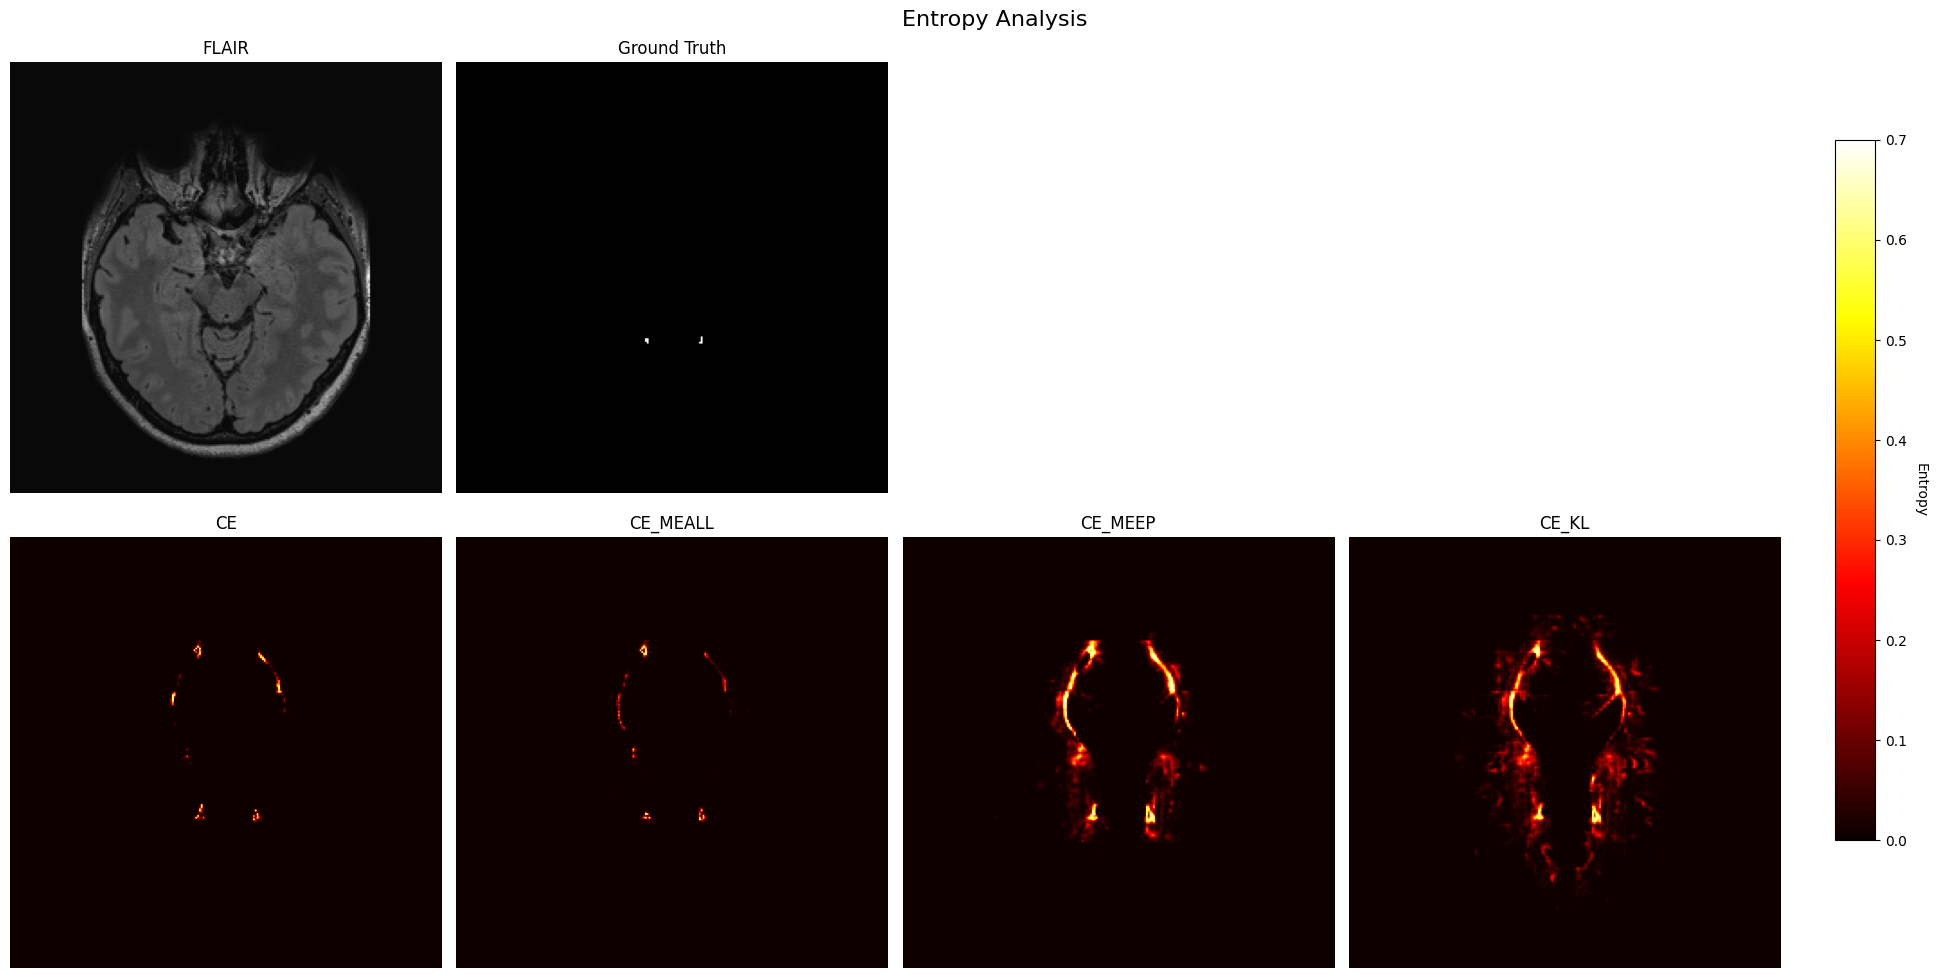

In [27]:
display_example(subject)

### Dice vs entropy

#### Definition

In [24]:

from scipy.stats import pearsonr


def dice_vs_entropy(plot_data, entropy_mask='softmax_pos_class',
                    loss_centers_tendencies=False,
                    loss_tendencies=True, print_ideal=False, dice_mask=None,
                    logit_dice=False):
    centers_train, runs_to_compare, centers_test, test_splits, losses = plot_data.values()
    results = []

    test_center_rename = {
        "UtAmSi": "In-distribution",
        "UMCL": "Out-of-distribution"
    }

    for tr_center in centers_train:
        for loss in losses:
            run_name = runs_to_compare.get(f'{loss} {tr_center}')
            if run_name is None:
                print(f'No run for {loss} {tr_center}.')
                continue

            for ts_center in centers_test:
                gt_paths = get_gt_paths(test_splits[ts_center])
                for subj_path in gt_paths:
                    gt, pred_softmax, pred_hard, b_mask = load_images(
                        subj_path, run_name, get_b_mask_path(subj_path)
                    )

                    pos_class, hard_class, gt_class, b_mask = flatten_and_filter(
                        pred_softmax, pred_hard, gt, b_mask, entropy_mask,
                        dice_mask
                    )

                    dice_hard = dice_score(hard_class, gt_class)
                    entrop = entropy(pos_class)
                    results.append({
                        'Loss': loss, 'Test_Center': ts_center,
                        'Dice': dice_hard, 'Entropy': entrop
                    })
    df = pd.DataFrame(results)

    unique_centers = df['Test_Center'].unique()
    unique_losses = df['Loss'].unique()

    fig, ax = plt.subplots(figsize=(6, 5))  # Reduced figure size

    if logit_dice:
        df['Logit_Dice'] = np.log(df['Dice'] / (1 - df['Dice']))
        scatter = sns.scatterplot(data=df, x='Logit_Dice', y='Entropy',
                                  hue='Loss', style='Test_Center', s=50)
        ax.set_xlabel('Logit(Dice Coefficient)', fontsize=12)
    else:
        scatter = sns.scatterplot(data=df, x='Dice', y='Entropy', hue='Loss',
                                  style='Test_Center', s=50)
        ax.set_xlabel('Dice Coefficient', fontsize=12)

    if print_ideal:
        ax.plot([0, 1], [1, 0], linestyle='--', color='black', linewidth=1,
                label='Ideal')

    if loss_centers_tendencies:
        for loss in losses:
            for center in centers_test:
                subset = df[
                    (df['Loss'] == loss) & (df['Test_Center'] == center)]
                if not subset.empty:
                    sns.regplot(x='Dice' if not logit_dice else 'Logit_Dice',
                                y='Entropy', data=subset, scatter=False,
                                ci=None, ax=ax, line_kws={'linewidth': 1})

    if loss_tendencies:
        for loss in losses:
            subset = df[df['Loss'] == loss]
            if not subset.empty:
                sns.regplot(x='Dice' if not logit_dice else 'Logit_Dice',
                            y='Entropy', data=subset, scatter=False, ci=None,
                            ax=ax, line_kws={'linewidth': 1})

    ax.set_title('Dice vs. Entropy', fontsize=14, pad=10)
    ax.set_ylabel('Entropy', fontsize=12)
    ax.tick_params(axis='both', which='major', labelsize=10)
    if not logit_dice:
        ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])

    # Remove the default legend
    ax.get_legend().remove()

    # Calculate Spearman correlations and find the maximum length of loss names for alignment
    max_len = max(len(loss.split('_')[1] if '_' in loss else loss) for loss in
                  unique_losses)

    # Create custom legend elements
    palette = sns.color_palette(n_colors=len(unique_losses))
    loss_elements = []
    for i, loss in enumerate(unique_losses):
        subset = df[df['Loss'] == loss]
        if not subset.empty:
            corr, _ = pearsonr(subset['Dice'], subset['Entropy'])
            corr, _ = spearmanr(subset['Dice'], subset['Entropy'])
            loss_name = loss.split('_')[1] if '_' in loss else loss
            padded_loss_name = f"{loss_name}{' ' * (max_len - len(loss_name))}"  # Adding this padding doesn't work because they're still disaligned
            loss_label = f"{padded_loss_name} ({corr:.3f})"
            loss_elements.append(
                plt.Line2D([0], [0], marker='s', color=palette[i], linestyle='',
                           markersize=8, label=loss_label))

    center_elements = [
        plt.Line2D([0], [0], marker='o' if center == 'UMCL' else 'x',
                   color='black', linestyle='', markersize=8, label=center)
        for center in unique_centers]

    if rename_centers:
        for i, center in enumerate(center_elements):
            center_elements[i].set_label(
                rename_centers.get(center.get_label(), center.get_label()))
    # Sort center elements alphabetically
    center_elements = sorted(center_elements, key=lambda x: x.get_label())

    # Add empty elements to ensure column break
    num_loss = len(loss_elements)
    num_center = len(center_elements)
    max_elements = max(num_loss, num_center)

    loss_elements = [plt.Line2D([0], [0], marker='', linestyle='',
                                label='Loss')] + loss_elements
    loss_elements += [plt.Line2D([0], [0], marker='', linestyle='',
                                 label='')] * (max_elements - num_loss)
    center_elements = [plt.Line2D([0], [0], marker='', linestyle='',
                                  label='Data')] + center_elements
    center_elements += [plt.Line2D([0], [0], marker='', linestyle='',
                                   label='')] * (max_elements - num_center)

    # Combine all legend elements
    all_elements = loss_elements + center_elements
    # Create a single legend with two columns
    legend = ax.legend(handles=all_elements, fontsize=8,
                       bbox_to_anchor=(1.05, 1), loc='upper left',
                       ncol=2, columnspacing=1, handletextpad=0.5)
    for text in legend.get_texts():
        text.set_fontname('DejaVu Sans Mono')
    plt.tight_layout()
    plt.subplots_adjust(right=0.75)  # Adjust right margin for legend

    # Save the figure as a PDF file
    plt.savefig('dice_vs_entropy.pdf', format='pdf', bbox_inches='tight')
    plt.show()

#### Image

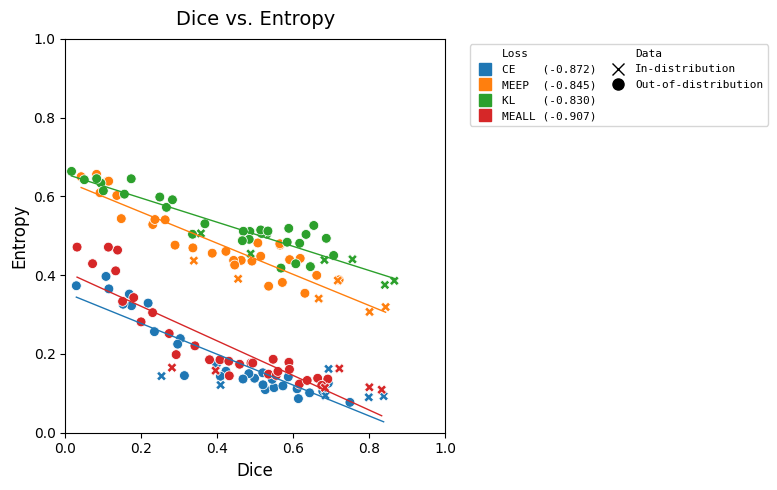

In [25]:
dice_vs_entropy(plot_data, entropy_mask='softmax_pos_class',
                loss_centers_tendencies=False, loss_tendencies=True,
                print_ideal=False, logit_dice=False)

In [ ]:
def entropy_boxes(plot_data, m_type='softmax_pos_class'):
    """ Plot entropy scores for each run

    :param plot_data: Dictionary with the required data for plotting (same
    for all plotting functions)
    :param m_type: Type of mask to use for entropy calculation. Options:
    'softmax_pos_class', 'gt', 'brain_mask'.
    """

    centers_train, runs_to_compare, centers_test, test_splits, losses = plot_data.values()

    test_center_rename = {
        "UtAmSi": "In-distribution",
        "UMCL": "Out-of-distribution"
    }

    for tr_center in centers_train:  # Three plots: one per center used for training
        plot_data = {}  # Entropy scores for each run
        for loss in losses:  # One subplot per loss
            plot_data[loss] = {}
            run_name = runs_to_compare[f'{loss} {tr_center}']
            if f'{loss} {tr_center}' not in runs_to_compare.keys():
                print(f'No run for {run_name}.')
                continue
            for ts_center in centers_test:  # For each center used for testing
                renamed_center = test_center_rename.get(ts_center, ts_center)
                plot_data[loss][renamed_center] = []
                gt_pths = get_gt_paths(
                    test_splits[ts_center])  # Lst of tst sbj pts
                for subj_path in gt_pths:
                    gt_path = os.path.join(subj_path,
                                           f'gt_wmh_{run_name}.nii.gz')
                    pred_softmax_path = os.path.join(subj_path,
                                                     f'pred_wmh_softmax_{run_name}.nii.gz')

                    gt = nib.load(gt_path).get_fdata()
                    pred_softmax = nib.load(pred_softmax_path).get_fdata()
                    b_mask = nib.load(
                        get_b_mask_path(subj_path)).get_fdata()

                    pos_class = pred_softmax[:, :, :, 1].flatten()
                    gt_class = gt.flatten()
                    b_mask = b_mask.flatten()

                    if m_type == 'softmax_pos_class':
                        filt = pos_class[np.where(pos_class >= 0.5)[0]]
                    elif m_type == 'gt':
                        filt = pos_class[np.where(gt_class == 1)[0]]
                    else:
                        filt = pos_class[np.where(b_mask == 1)[0]]

                    plot_data[loss][renamed_center].append(entropy(filt))
        df = pd.DataFrame(plot_data)

        # Prepare data for plotting
        plot_df = []
        for loss in losses:
            for ts_center in centers_test:
                renamed_center = test_center_rename.get(ts_center, ts_center)
                entropy_values = plot_data[loss][renamed_center]
                plot_df.extend([{
                    'Loss': loss,
                    'Distribution': renamed_center,
                    'Entropy': value
                } for value in entropy_values])

        df = pd.DataFrame(plot_df)

        # Set up the plot
        plt.figure(figsize=(8, 3))
        sns.set_style("whitegrid")
        sns.set_palette("deep")

        # Create the box plot with reversed hue order
        ax = sns.boxplot(x="Loss", y="Entropy", hue="Distribution", data=df,
                         width=0.7, fliersize=2,
                         hue_order=["In-distribution", "Out-of-distribution"])

        # Add statistical annotations
        box_pairs = []
        for loss in losses:
            box_pairs.append(
                ((loss, "In-distribution"), (loss, "Out-of-distribution")))

        add_stat_annotation(ax, data=df, x="Loss", y="Entropy",
                            hue="Distribution",
                            box_pairs=box_pairs,
                            test='Mann-Whitney', text_format='star',
                            loc='inside', verbose=2)

        # Customize the plot
        plt.title("Entropy per loss and distribution", fontsize=14)
        plt.xlabel("Loss Function", fontsize=12)
        plt.ylabel("Entropy", fontsize=12)

        # Move legend outside and to the right
        plt.legend(title="Distribution", title_fontsize=12, fontsize=10,
                   bbox_to_anchor=(1.05, 1), loc='upper left')

        # Remove x-axis label rotation
        plt.xticks(rotation=0)

        # Adjust layout and display
        plt.tight_layout()
        plt.show()

        # Compute and print Mann-Whitney U tests
        print(f'Mann-Whitney U test results for {tr_center} training:')
        for loss in losses:
            renamed_centers = [test_center_rename.get(c, c) for c in
                               centers_test]
            for ts_center_1 in renamed_centers:
                for ts_center_2 in renamed_centers:
                    if ts_center_1 != ts_center_2:
                        data1 = plot_data[loss][ts_center_1]
                        data2 = plot_data[loss][ts_center_2]
                        stat, p_value = stats.mannwhitneyu(data1, data2,
                                                           alternative='two-sided')
                        print(
                            f'Loss: {loss}, Test Centers: {ts_center_1} vs {ts_center_2}, p-value: {p_value}')

p-value annotation legend:
ns: 5.00e-02 < p <= 1.00e+00
*: 1.00e-02 < p <= 5.00e-02
**: 1.00e-03 < p <= 1.00e-02
***: 1.00e-04 < p <= 1.00e-03
****: p <= 1.00e-04

CE_MEEP_Out-of-distribution v.s. CE_MEEP_In-distribution: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=6.309e-03 U_stat=2.940e+02
CE_Out-of-distribution v.s. CE_In-distribution: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=2.564e-01 U_stat=2.470e+02
CE_KL_Out-of-distribution v.s. CE_KL_In-distribution: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=2.654e-02 U_stat=2.780e+02
CE_MEALL_Out-of-distribution v.s. CE_MEALL_In-distribution: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=5.083e-02 U_stat=2.700e+02


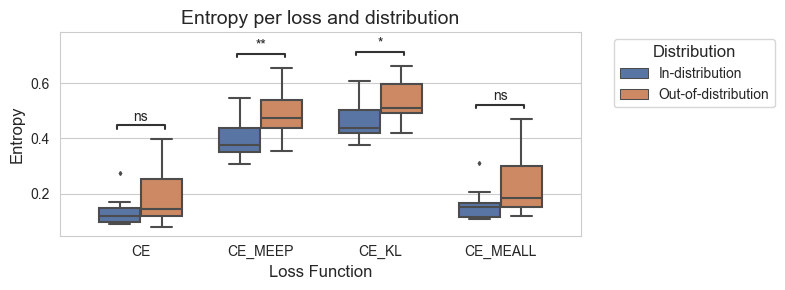

Mann-Whitney U test results for UtAmSi training:
Loss: CE, Test Centers: Out-of-distribution vs In-distribution, p-value: 0.0640957712891108
Loss: CE, Test Centers: In-distribution vs Out-of-distribution, p-value: 0.0640957712891108
Loss: CE_MEEP, Test Centers: Out-of-distribution vs In-distribution, p-value: 0.0015771428701617436
Loss: CE_MEEP, Test Centers: In-distribution vs Out-of-distribution, p-value: 0.0015771428701617436
Loss: CE_KL, Test Centers: Out-of-distribution vs In-distribution, p-value: 0.006635096006711722
Loss: CE_KL, Test Centers: In-distribution vs Out-of-distribution, p-value: 0.006635096006711722
Loss: CE_MEALL, Test Centers: Out-of-distribution vs In-distribution, p-value: 0.012706679316094907
Loss: CE_MEALL, Test Centers: In-distribution vs Out-of-distribution, p-value: 0.012706679316094907


In [79]:
entropy_boxes(plot_data, m_type='softmax_pos_class')

In [11]:
from statannot import add_stat_annotation
from scipy import stats


def dice_boxes(plot_data):
    """ Plot Dice scores for each run

    :param plot_data: Dictionary with the required data for plotting
    """
    centers_train, runs_to_compare, centers_test, test_splits, losses = plot_data.values()

    test_center_rename = {
        "UtAmSi": "In-distribution",
        "UMCL": "Out-of-distribution"
    }

    for tr_center in centers_train:  # One plot per center used for training
        plot_data = {}  # Dice scores for each run
        for loss in losses:  # One subplot per loss
            plot_data[loss] = {}
            run_name = runs_to_compare[f'{loss} {tr_center}']
            if f'{loss} {tr_center}' not in runs_to_compare.keys():
                print(f'No run for {run_name}.')
                continue
            for ts_center in centers_test:  # For each center used for testing
                renamed_center = test_center_rename.get(ts_center, ts_center)
                plot_data[loss][renamed_center] = []
                gt_pths = get_gt_paths(
                    test_splits[ts_center])  # List of test subject paths
                for subj_path in gt_pths:
                    gt_path = os.path.join(subj_path,
                                           f'gt_wmh_{run_name}.nii.gz')
                    pred_softmax_path = os.path.join(subj_path,
                                                     f'pred_wmh_softmax_{run_name}.nii.gz')

                    gt = nib.load(gt_path).get_fdata()
                    pred_softmax = nib.load(pred_softmax_path).get_fdata()

                    # Convert softmax predictions to binary mask
                    pred_binary = (pred_softmax[:, :, :, 1] >= 0.5).astype(int)

                    # Compute Dice score
                    dice = dice_score(gt, pred_binary)
                    plot_data[loss][renamed_center].append(dice)

        # Prepare data for plotting
        plot_df = []
        for loss in losses:
            for ts_center in centers_test:
                renamed_center = test_center_rename.get(ts_center, ts_center)
                dice_values = plot_data[loss][renamed_center]
                plot_df.extend([{
                    'Loss': loss,
                    'Distribution': renamed_center,
                    'Dice Score': value
                } for value in dice_values])

        df = pd.DataFrame(plot_df)

        # Set up the plot
        plt.figure(figsize=(8, 3))
        sns.set_style("whitegrid")
        sns.set_palette("deep")

        # Create the box plot with reversed hue order
        ax = sns.boxplot(x="Loss", y="Dice Score", hue="Distribution", data=df,
                         width=0.7, fliersize=2,
                         hue_order=["In-distribution", "Out-of-distribution"])

        # Add statistical annotations
        box_pairs = []
        for loss in losses:
            box_pairs.append(
                ((loss, "In-distribution"), (loss, "Out-of-distribution")))

        add_stat_annotation(ax, data=df, x="Loss", y="Dice Score",
                            hue="Distribution",
                            box_pairs=box_pairs,
                            test='Mann-Whitney', text_format='star',
                            loc='inside', verbose=2)

        # Customize the plot
        plt.title(f"Dice Coefficient for loss and distribution", fontsize=14)
        plt.xlabel("Loss Function", fontsize=12)
        plt.ylabel("Dice Score", fontsize=12)

        # Move legend outside and to the right
        plt.legend(title="Distribution", title_fontsize=12, fontsize=10,
                   bbox_to_anchor=(1.05, 1), loc='upper left')

        # Remove x-axis label rotation
        plt.xticks(rotation=0)

        # Adjust layout and display
        plt.tight_layout()
        plt.show()

        # Compute and print Mann-Whitney U tests
        print(f'Mann-Whitney U test results for {tr_center} training:')
        for loss in losses:
            renamed_centers = [test_center_rename.get(c, c) for c in
                               centers_test]
            for ts_center_1 in renamed_centers:
                for ts_center_2 in renamed_centers:
                    if ts_center_1 != ts_center_2:
                        data1 = plot_data[loss][ts_center_1]
                        data2 = plot_data[loss][ts_center_2]
                        stat, p_value = stats.mannwhitneyu(data1, data2,
                                                           alternative='two-sided')
                        print(
                            f'Loss: {loss}, Test Centers: {ts_center_1} vs {ts_center_2}, p-value: {p_value}')

p-value annotation legend:
ns: 5.00e-02 < p <= 1.00e+00
*: 1.00e-02 < p <= 5.00e-02
**: 1.00e-03 < p <= 1.00e-02
***: 1.00e-04 < p <= 1.00e-03
****: p <= 1.00e-04

CE_MEEP_Out-of-distribution v.s. CE_MEEP_In-distribution: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=8.376e-03 U_stat=6.900e+01
CE_Out-of-distribution v.s. CE_In-distribution: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=4.698e-02 U_stat=8.900e+01
CE_KL_Out-of-distribution v.s. CE_KL_In-distribution: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=8.376e-03 U_stat=6.900e+01
CE_MEALL_Out-of-distribution v.s. CE_MEALL_In-distribution: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=2.056e-02 U_stat=7.900e+01


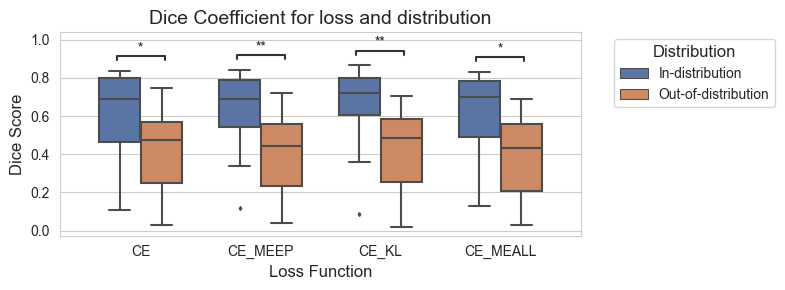

Mann-Whitney U test results for UtAmSi training:
Loss: CE, Test Centers: Out-of-distribution vs In-distribution, p-value: 0.011744543066279579
Loss: CE, Test Centers: In-distribution vs Out-of-distribution, p-value: 0.011744543066279579
Loss: CE_MEEP, Test Centers: Out-of-distribution vs In-distribution, p-value: 0.002093940351095057
Loss: CE_MEEP, Test Centers: In-distribution vs Out-of-distribution, p-value: 0.002093940351095057
Loss: CE_KL, Test Centers: Out-of-distribution vs In-distribution, p-value: 0.002093940351095057
Loss: CE_KL, Test Centers: In-distribution vs Out-of-distribution, p-value: 0.002093940351095057
Loss: CE_MEALL, Test Centers: Out-of-distribution vs In-distribution, p-value: 0.00513960179037091
Loss: CE_MEALL, Test Centers: In-distribution vs Out-of-distribution, p-value: 0.00513960179037091


In [12]:
dice_boxes(plot_data)

In [24]:
import numpy as np
from matplotlib.lines import Line2D


def uncertainty_confusion(plot_data, n_samples=1000):
    centers_train, runs_to_compare, centers_test, test_splits, losses = plot_data.values()

    test_center_rename = {
        "UtAmSi": "In-distribution",
        "UMCL": "Out-of-distribution"
    }

    for tr_center in centers_train:
        plot_data = {}
        mean_data = {}
        median_data = {}
        for loss in losses:
            plot_data[loss] = {}
            mean_data[loss] = {}
            median_data[loss] = {}
            run_name = runs_to_compare[f'{loss} {tr_center}']
            if f'{loss} {tr_center}' not in runs_to_compare.keys():
                print(f'No run for {run_name}.')
                continue
            for ts_center in centers_test:
                plot_data[loss][ts_center] = {
                    "TP": np.array([]),
                    "FP": np.array([]),
                    "TN": np.array([]),
                    "FN": np.array([])
                }
                mean_data[loss][ts_center] = {}
                median_data[loss][ts_center] = {}
                gt_pths = get_gt_paths(test_splits[ts_center])
                for subj_path in gt_pths:
                    pred_softmax_path = os.path.join(subj_path,
                                                     f'pred_wmh_softmax_{run_name}.nii.gz')
                    gt_path = os.path.join(subj_path,
                                           f'gt_wmh_{run_name}.nii.gz')

                    subj_path = os.path.dirname(pred_softmax_path)

                    pred_softmax = nib.load(pred_softmax_path).get_fdata()
                    gt = nib.load(gt_path).get_fdata()
                    b_mask = nib.load(get_b_mask_path(subj_path)).get_fdata()

                    gt_one_hot = np.eye(2, dtype=np.uint8)[gt.astype(int)]

                    neg_sftmx = pred_softmax[:, :, :, 0].flatten()
                    pos_sftmx = pred_softmax[:, :, :, 1].flatten()
                    neg_gt = gt_one_hot[:, :, :, 0].flatten()
                    pos_gt = gt_one_hot[:, :, :, 1].flatten()

                    b_mask = b_mask.flatten()

                    thres_brain = np.where(b_mask == 1)[0]
                    pos_brain = pos_sftmx[thres_brain]
                    neg_brain = neg_sftmx[thres_brain]
                    pos_gt_brain = pos_gt[thres_brain]
                    neg_gt_brain = neg_gt[thres_brain]

                    tp = np.where((pos_brain >= 0.5) & (pos_gt_brain == 1))[0]
                    tp_unc = entropy(pos_brain[tp], apply_mean=False)
                    plot_data[loss][ts_center]["TP"] = np.append(
                        plot_data[loss][ts_center]["TP"], tp_unc)

                    fp = np.where((pos_brain >= 0.5) & (pos_gt_brain == 0))[0]
                    fp_unc = entropy(pos_brain[fp], apply_mean=False)
                    plot_data[loss][ts_center]["FP"] = np.append(
                        plot_data[loss][ts_center]["FP"], fp_unc)

                    tn = np.where((neg_brain >= 0.5) & (neg_gt_brain == 1))[0]
                    tn_unc = entropy(neg_brain[tn], apply_mean=False)
                    plot_data[loss][ts_center]["TN"] = np.append(
                        plot_data[loss][ts_center]["TN"], tn_unc)

                    fn = np.where((neg_brain >= 0.5) & (neg_gt_brain == 0))[0]
                    fn_unc = entropy(neg_brain[fn], apply_mean=False)
                    plot_data[loss][ts_center]["FN"] = np.append(
                        plot_data[loss][ts_center]["FN"], fn_unc)

                    if n_samples:
                        for category in plot_data[loss][ts_center].keys():
                            if len(plot_data[loss][ts_center][
                                       category]) > n_samples:
                                plot_data[loss][ts_center][
                                    category] = np.random.choice(
                                    plot_data[loss][ts_center][category],
                                    n_samples,
                                    replace=False)

                for category in ["TP", "TN", "FP", "FN"]:
                    mean_values = np.mean(plot_data[loss][ts_center][category])
                    median_values = np.median(
                        plot_data[loss][ts_center][category])
                    mean_data[loss][ts_center][category] = mean_values
                    median_data[loss][ts_center][category] = median_values

    fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharey=True)
    axes = axes.flatten()  # Flatten the 2x2 grid to iterate easily
    categories = ["TP", "TN", "FP", "FN"]

    for i, category in enumerate(categories):
        data = []
        for distribution in ["In-distribution", "Out-of-distribution"]:
            for loss in losses:
                for center, metrics in plot_data[loss].items():
                    renamed_center = test_center_rename.get(center, center)
                    if renamed_center == distribution:
                        data.extend(
                            [(category, loss, distribution, value) for value in
                             metrics[category]])

        df = pd.DataFrame(data,
                          columns=['Metric', 'Loss', 'Distribution', 'Value'])

        custom_order = df['Loss'].unique()

        x_positions = np.arange(len(custom_order) * 2)

        # Plot all in-distribution first, then all out-of-distribution
        for j, dist in enumerate(['In-distribution', 'Out-of-distribution']):
            df_dist = df[df['Distribution'] == dist]
            color = '#1f77b4' if dist == 'In-distribution' else '#ff7f0e'

            for k, loss in enumerate(custom_order):
                group = df_dist[df_dist['Loss'] == loss]
                x = x_positions[k + j * len(custom_order)]
                y = group['Value']
                axes[i].scatter(x + np.random.normal(0, 0.05, len(y)), y,
                                color=color, alpha=0.2, s=3)

        for marker, data_source in zip(['D', 'o'], [mean_data, median_data]):
            summary_df = pd.DataFrame(
                [(category, loss, test_center_rename.get(center, center), value)
                 for loss, centers in data_source.items()
                 for center, metrics in centers.items()
                 for value in [metrics[category]]],
                columns=['Metric', 'Loss', 'Distribution', 'Value'])

            for j, dist in enumerate(
                    ['In-distribution', 'Out-of-distribution']):
                df_dist = summary_df[summary_df['Distribution'] == dist]
                for k, loss in enumerate(custom_order):
                    group = df_dist[df_dist['Loss'] == loss]
                    if not group.empty:
                        x = x_positions[k + j * len(custom_order)]
                        y = group['Value'].values[0]
                        axes[i].scatter(x, y, color='#d62728', marker=marker,
                                        s=64)

        axes[i].set_title(f'{category}', fontsize=16, pad=10)
        # axes[i].set_xlabel('Loss', fontsize=14)
        if i == 0:
            axes[i].set_ylabel('Entropy', fontsize=14)
        axes[i].tick_params(axis='both', which='major', labelsize=12)
        axes[i].set_xticks(x_positions)
        axes[i].set_xticklabels(custom_order.tolist() * 2, rotation=45,
                                ha='right')

        # Remove background grid lines
        axes[i].grid(False)

    # Create custom legend
    legend_elements = [
        Line2D([0], [0], color='#1f77b4', lw=4, label='In-distribution'),
        Line2D([0], [0], color='#ff7f0e', lw=4, label='Out-of-distribution'),
        Line2D([0], [0], marker='D', color='w', markerfacecolor='#d62728',
               markersize=8, label='Mean'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#d62728',
               markersize=8, label='Median')
    ]

    legend = fig.legend(handles=legend_elements,
                        bbox_to_anchor=(0.865, 0.5), loc='center left',
                        fontsize=10)
    legend.get_title().set_fontsize(12)

    fig.text(0.5, 0.002, 'Loss', ha='center', fontsize=14)
    plt.tight_layout()
    plt.suptitle(f'Uncertainty by error type', fontsize=18, y=1.05)
    plt.subplots_adjust(right=0.85)  # Adjust right margin for legend
    plt.show()

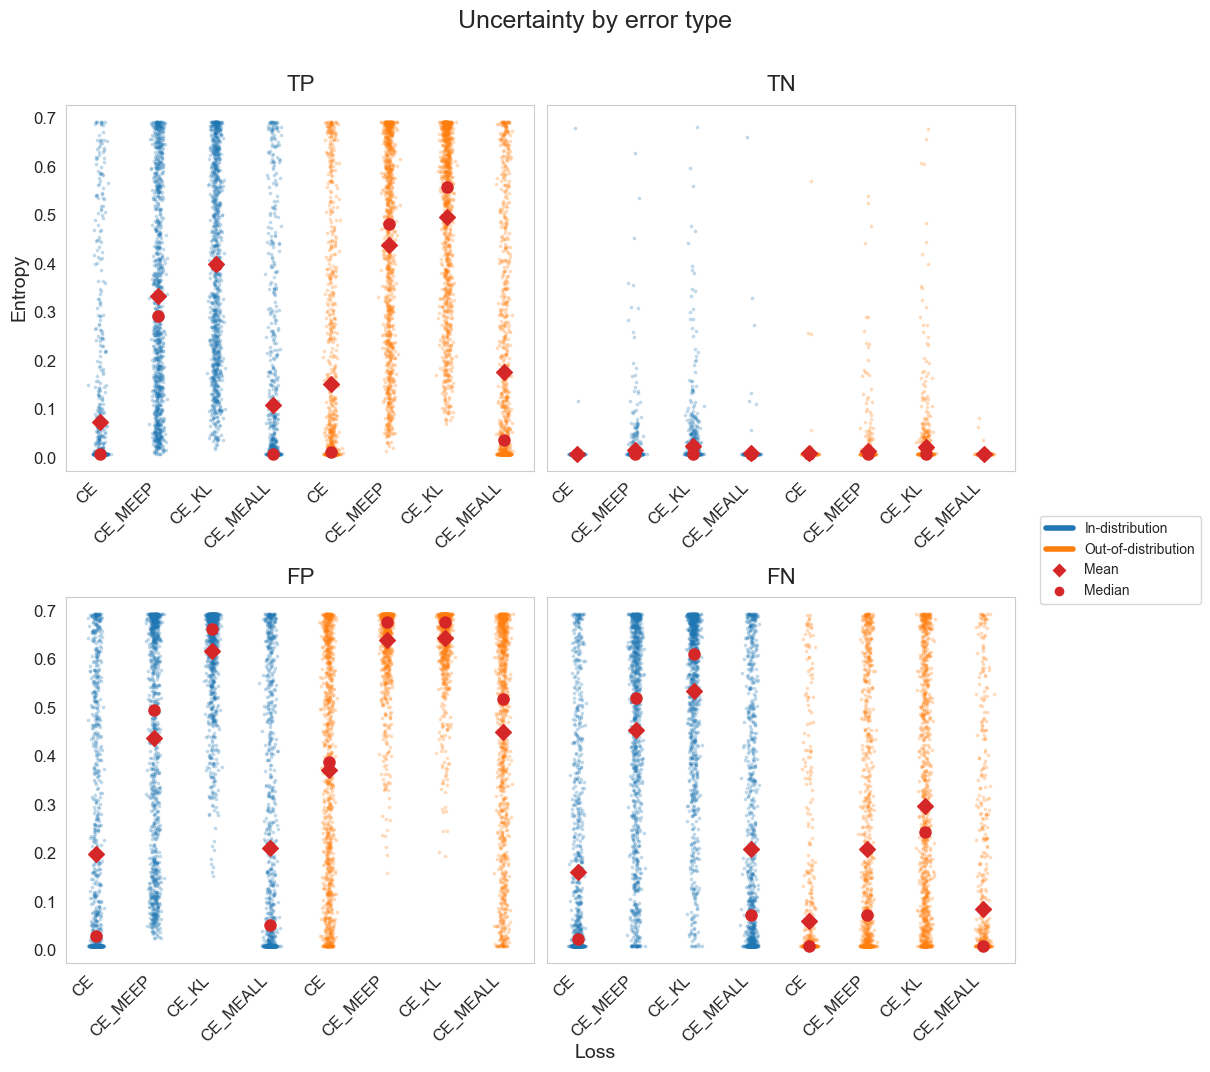

In [25]:
uncertainty_confusion(plot_data, n_samples=1000)

In [91]:
volume_ranges = [(0, 5), (5, 15), (15, np.inf)]

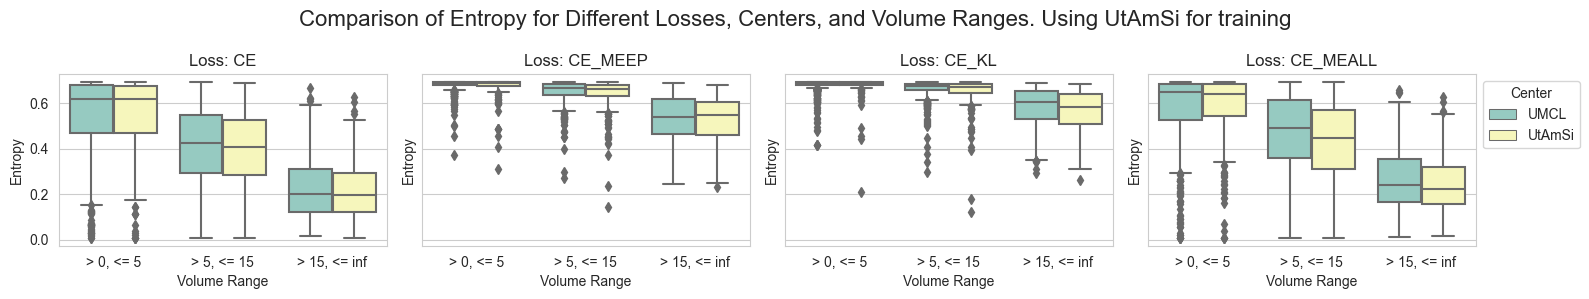

In [27]:
from notebooks.metrics.utils import entropy_volume_ranges

entropy_volume_ranges(plot_data, volume_ranges)

In [ ]:

import numpy as np
from scipy.stats import entropy


def entropy_volume_ranges(plot_data,
                          volume_ranges=((0, 5), (5, 15), (15, np.inf))):
    centers_train, runs_to_compare, centers_test, test_splits, losses = plot_data.values()

    rename_centers = {'UtAmSi': 'In-distribution',
                      'UMCL': 'Out-of-distribution'}
    loss_order = ['CE', 'CE_MEALL', 'CE_MEEP', 'CE_KL']

    for tr_center in centers_train:
        plot_data = {}
        for loss in losses:
            plot_data[loss] = {}
            run_name = runs_to_compare[f'{loss} {tr_center}']
            if f'{loss} {tr_center}' not in runs_to_compare.keys():
                print(f'No run for {run_name}.')
                continue
            for ts_center in centers_test:
                plot_data[loss][ts_center] = {
                    f"> {volume_ranges[i][0]}, <= {volume_ranges[i][1]}": []
                    for i in range(len(volume_ranges))
                }
                gt_pths = get_gt_paths(test_splits[ts_center])
                for subj_path in gt_pths:
                    pred_softmax_path = os.path.join(subj_path,
                                                     f'pred_wmh_softmax_{run_name}.nii.gz')

                    pred_softmax = sitk.ReadImage(pred_softmax_path)
                    hard_pred = sitk.GetArrayFromImage(pred_softmax).argmax(
                        axis=0)

                    cc = sitk.ConnectedComponent(sitk.GetImageFromArray(
                        (hard_pred > 0).astype(np.uint8)))
                    cc = sitk.RelabelComponent(cc)

                    for i in range(1, sitk.GetArrayFromImage(cc).max() + 1):
                        cc_mask_f = sitk.GetArrayFromImage(cc == i).flatten()
                        filt = np.where(cc_mask_f == 1)[0]
                        volume = len(filt) * np.prod(pred_softmax.GetSpacing())
                        sftmx_f = \
                            sitk.GetArrayFromImage(pred_softmax).flatten()[filt]
                        ent = entropy(sftmx_f)

                        for i, (lower, upper) in enumerate(volume_ranges):
                            if lower < volume <= upper:
                                plot_data[loss][ts_center][
                                    f"> {lower}, <= {upper}"].append(ent)
                                break

        # Prepare the data for plotting
        data = []
        for loss in losses:
            for center in centers_test:
                for range_label, entropies in plot_data[loss][center].items():
                    renamed_center = rename_centers.get(center, center)
                    data.extend(
                        [(loss, renamed_center, range_label, ent) for ent in
                         entropies])

        df = pd.DataFrame(data,
                          columns=['Loss', 'Center', 'Volume Range', 'Entropy'])

        # Create a single plot
        plt.figure(figsize=(20, 6))

        # Define the order of centers
        center_order = ['In-distribution', 'Out-of-distribution']

        # Create a boxplot for each volume range
        for i, volume_range in enumerate(df['Volume Range'].unique()):
            ax = plt.subplot(1, 3, i + 1)

            # Filter the DataFrame for the current volume range
            range_df = df[df['Volume Range'] == volume_range]

            # Create boxplots for each loss and center
            sns.boxplot(data=range_df, x='Loss', y='Entropy', hue='Center',
                        order=loss_order, hue_order=center_order,
                        palette={'In-distribution': 'lightgreen',
                                 'Out-of-distribution': 'lightblue'})

            plt.title(f'Volume Range: {volume_range}')
            plt.xlabel('Loss')
            plt.ylabel('Entropy')

            # Rotate x-axis labels for better readability
            plt.xticks(rotation=45)

            # Only show legend for the last subplot
            if i < 2:
                plt.legend([], [], frameon=False)

        # Set the overall title for the entire plot
        plt.suptitle(
            'Comparison of Entropy for Different Losses, Centers, and '
            f'Volume Ranges. Using {tr_center} for training',
            fontsize=16)

        # Adjust the layout
        plt.tight_layout()
        plt.show()

# You would call this function with your plot_data dictionary as before

In [31]:

import numpy as np


def entropy_volume_ranges(plot_data,
                          volume_ranges=((0, 5), (5, 15), (15, np.inf))):
    centers_train, runs_to_compare, centers_test, test_splits, losses = plot_data.values()

    rename_centers = {'UtAmSi': 'In-distribution',
                      'UMCL': 'Out-of-distribution'}
    loss_order = ['CE', 'CE_MEALL', 'CE_MEEP', 'CE_KL']

    for tr_center in centers_train:
        plot_data = {}
        for loss in losses:
            plot_data[loss] = {}
            run_name = runs_to_compare[f'{loss} {tr_center}']
            if f'{loss} {tr_center}' not in runs_to_compare.keys():
                print(f'No run for {run_name}.')
                continue
            for ts_center in centers_test:
                plot_data[loss][ts_center] = {
                    f"> {volume_ranges[i][0]}, <= {volume_ranges[i][1]}": []
                    for i in range(len(volume_ranges))
                }
                gt_pths = get_gt_paths(test_splits[ts_center])
                for subj_path in gt_pths:
                    pred_softmax_path = os.path.join(subj_path,
                                                     f'pred_wmh_softmax_{run_name}.nii.gz')

                    pred_softmax = sitk.ReadImage(pred_softmax_path)
                    hard_pred = sitk.GetArrayFromImage(pred_softmax).argmax(
                        axis=0)

                    cc = sitk.ConnectedComponent(sitk.GetImageFromArray(
                        (hard_pred > 0).astype(np.uint8)))
                    cc = sitk.RelabelComponent(cc)

                    for i in range(1, sitk.GetArrayFromImage(cc).max() + 1):
                        cc_mask_f = sitk.GetArrayFromImage(cc == i).flatten()
                        filt = np.where(cc_mask_f == 1)[0]
                        volume = len(filt) * np.prod(pred_softmax.GetSpacing())
                        sftmx_f = \
                            sitk.GetArrayFromImage(pred_softmax).flatten()[filt]
                        ent = entropy(sftmx_f, apply_mean=True)

                        for i, (lower, upper) in enumerate(volume_ranges):
                            if lower < volume <= upper:
                                plot_data[loss][ts_center][
                                    f"> {lower}, <= {upper}"].append(ent)
                                break

    # Prepare the data for plotting
    data = []
    for loss in losses:
        for center in centers_test:
            for range_label, entropies in plot_data[loss][center].items():
                renamed_center = rename_centers.get(center, center)
                data.extend([(loss, renamed_center, range_label, ent) for ent in
                             entropies])

    df = pd.DataFrame(data,
                      columns=['Loss', 'Center', 'Volume Range', 'Entropy'])
    # Create a single plot
    fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

    # Define the order of centers
    center_order = ['In-distribution', 'Out-of-distribution']

    # Find global min and max for consistent y-axis
    # global_min = df['Entropy'].min()
    # global_max = df['Entropy'].max()

    # Create a boxplot for each volume range
    for i, volume_range in enumerate(df['Volume Range'].unique()):
        ax = axes[i]

        # Filter the DataFrame for the current volume range
        range_df = df[df['Volume Range'] == volume_range]

        # Create boxplots for each loss and center
        sns.boxplot(data=range_df, x='Loss', y='Entropy', hue='Center',
                    order=loss_order, hue_order=center_order,
                    palette={'In-distribution': 'lightgreen',
                             'Out-of-distribution': 'lightblue'},
                    ax=ax)

        ax.set_title(f'Volume Range: {volume_range}')
        ax.set_xlabel('Loss')
        ax.set_ylabel('Entropy')

        # Rotate x-axis labels for better readability
        ax.set_xticklabels(ax.get_xticklabels())

        # Set y-axis limits consistently across subplots
        # ax.set_ylim(global_min, global_max)

        # Add median lines
        for i, artist in enumerate(ax.artists):
            col = artist.get_facecolor()
            artist.set_edgecolor(col)
            artist.set_facecolor('None')

            y = range_df[(range_df['Loss'] == loss_order[i // 2]) &
                         (range_df['Center'] == center_order[i % 2])][
                'Entropy'].median()
            ax.hlines(y, *artist.get_xy()[:2], colors=col, linestyles='--',
                      linewidth=2)

        # Only show legend for the last subplot
        if i < 2:
            ax.get_legend().remove()

    #move the legend outside the plot
    plt.legend(title='Center', title_fontsize=12, fontsize=10,
               bbox_to_anchor=(1.05, 1), loc='upper left')

    # Set the overall title for the entire plot
    fig.suptitle('Entropy per volume range', fontsize=16)

    # Adjust the layout
    plt.tight_layout()
    plt.show()

# You would call this function with your plot_data dictionary as before

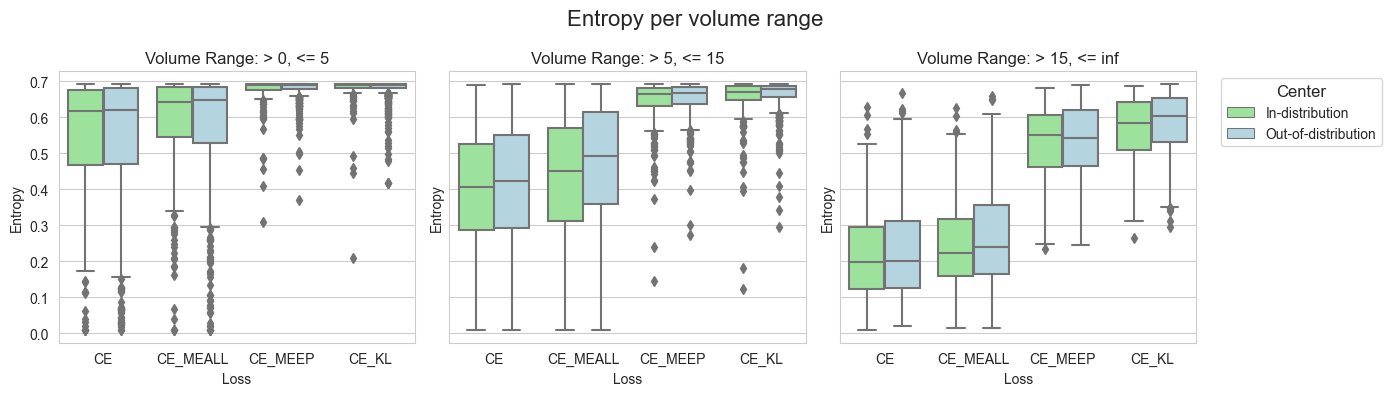

In [20]:
df = entropy_volume_ranges(plot_data, volume_ranges)

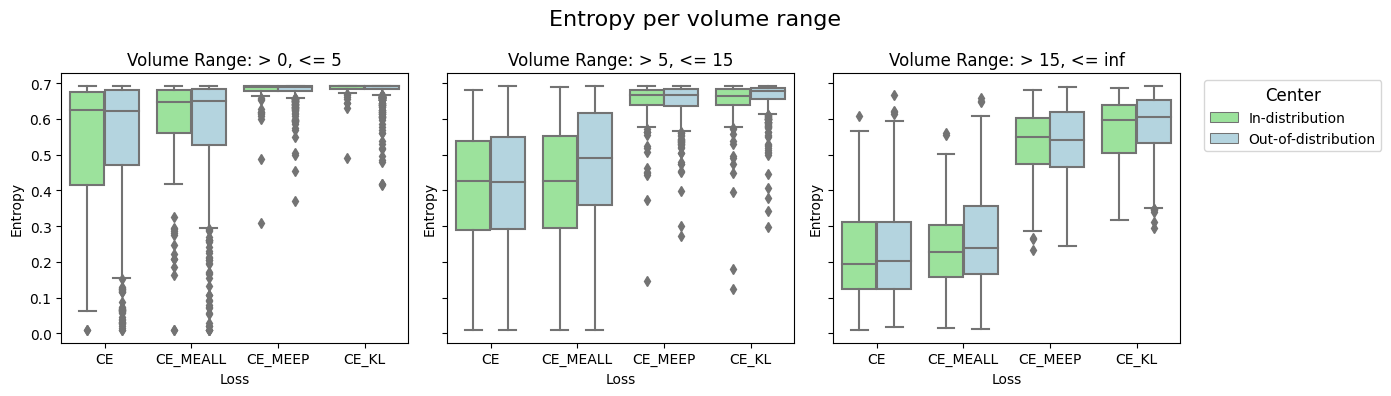

In [34]:
df = entropy_volume_ranges(plot_data, volume_ranges)

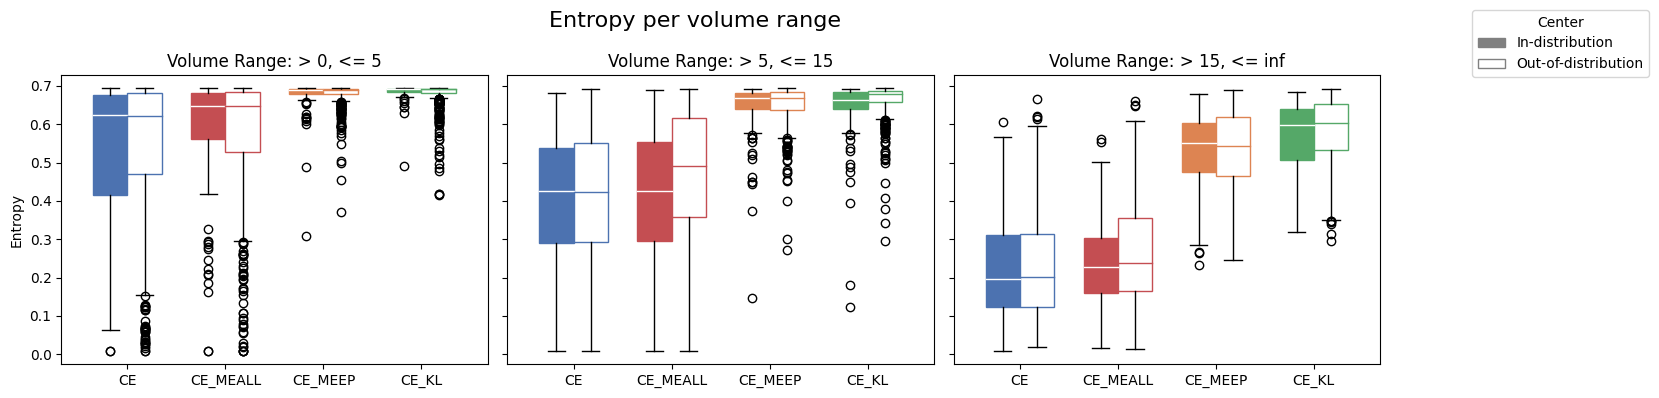

In [ ]:
  import matplotlib.patches as mpatches

def entropy_volume_ranges(data,
                          volume_ranges=((0, 5), (5, 15), (15, np.inf))):
    centers_train, runs_to_compare, centers_test, test_splits, losses = \
        data.values()

    rename_centers = {'UtAmSi': 'In-distribution',
                      'UMCL':   'Out-of-distribution'}
    loss_order   = ['CE','CE_MEALL','CE_MEEP','CE_KL']
    loss_colors  = {
        'CE':      '#4C72B0',
        'CE_MEALL':'#C44E52',
        'CE_MEEP': '#DD8452',
        'CE_KL':   '#55A868'
    }

    # 1) collect entropies per (loss, center, volume‐range)
    plot_dict = {loss: {c: {f"> {l}, <= {u}":[] 
                 for (l,u) in volume_ranges}
                 for c in centers_test}
                 for loss in losses}

    for tr in centers_train:
      for loss in losses:
        run_name = runs_to_compare.get(f"{loss} {tr}")
        for ts in centers_test:
          for subj in get_gt_paths(test_splits[ts]):
            pred = sitk.ReadImage(os.path.join(subj,
                      f"pred_wmh_softmax_{run_name}.nii.gz"))
            arr  = sitk.GetArrayFromImage(pred)
            hard = arr.argmax(axis=0)
            cc   = sitk.RelabelComponent(
                     sitk.ConnectedComponent(
                       sitk.GetImageFromArray((hard>0).astype(np.uint8))
                     )
                   )
            maxlabel = sitk.GetArrayFromImage(cc).max()
            for lbl in range(1, maxlabel+1):
              mask = sitk.GetArrayFromImage(cc==lbl).flatten()
              pts  = np.where(mask)[0]
              vol  = len(pts)*np.prod(pred.GetSpacing())
              probs= arr.flatten()[pts]
              ent  = entropy(probs, apply_mean=True)
              for (low,high),label in zip(volume_ranges, plot_dict[loss][ts]):
                if low < vol <= high:
                  plot_dict[loss][ts][label].append(ent)
                  break

    # 2) build DataFrame
    rows = []
    for loss in losses:
      for ts in centers_test:
        for vr, ents in plot_dict[loss][ts].items():
          for e in ents:
            rows.append((loss,
                         rename_centers[ts],
                         vr,
                         e))
    df = pd.DataFrame(rows,
                      columns=['Loss','Center','Volume Range','Entropy'])

    # 3) plot with matplotlib
    volume_ranges_labels = df['Volume Range'].unique()
    pos  = np.arange(len(loss_order))
    w    = 0.35

    fig, axes = plt.subplots(1, len(volume_ranges_labels),
                             figsize=(14,4), sharey=True)
    for ax, vr in zip(axes, volume_ranges_labels):
      vrdf = df[df['Volume Range']==vr]
      for i, loss in enumerate(loss_order):
        in_e  = vrdf[(vrdf['Loss']==loss)&(vrdf['Center']=='In-distribution')]['Entropy']
        out_e = vrdf[(vrdf['Loss']==loss)&(vrdf['Center']=='Out-of-distribution')]['Entropy']

        # filled
        ax.boxplot(in_e,
                   positions=[pos[i]-w/2],
                   widths=w,
                   patch_artist=True,
                   boxprops=dict(facecolor=loss_colors[loss],
                                 edgecolor=loss_colors[loss]),
                   medianprops=dict(color='white'))
        # hollow
        ax.boxplot(out_e,
                   positions=[pos[i]+w/2],
                   widths=w,
                   patch_artist=True,
                   boxprops=dict(facecolor='white',
                                 edgecolor=loss_colors[loss]),
                   medianprops=dict(color=loss_colors[loss]))

      ax.set_xticks(pos)
      ax.set_xticklabels(loss_order, rotation=0)
      ax.set_title(f'Volume Range: {vr}')
      if ax is axes[0]:
        ax.set_ylabel('Entropy')

    # legend for fill style only
    handles = [
      mpatches.Patch(facecolor='gray', edgecolor='gray', label='In-distribution'),
      mpatches.Patch(facecolor='white', edgecolor='gray', label='Out-of-distribution')
    ]
    fig.legend(handles=handles,
               title='Center',
               bbox_to_anchor=(1.05,1),
               loc='upper left')

    fig.suptitle('Entropy per volume range', fontsize=16)
    plt.tight_layout()
    plt.show()

# finally call it
entropy_volume_ranges(plot_data)

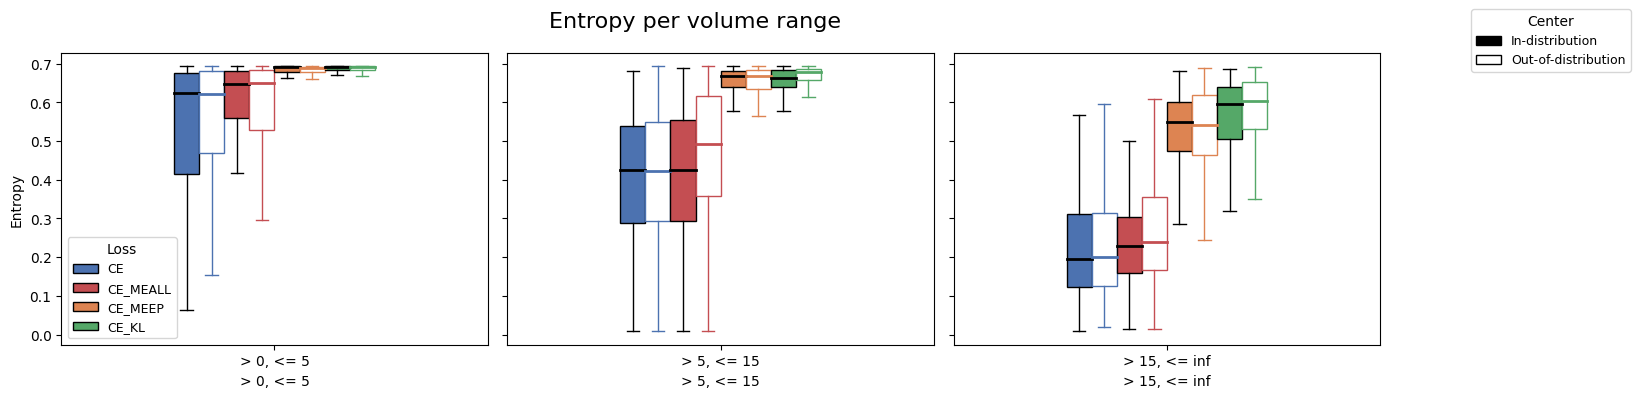

In [51]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import SimpleITK as sitk

# ensure entropy() and get_gt_paths() are defined elsewhere

def entropy_volume_ranges(data,
                          volume_ranges=((0, 5), (5, 15), (15, np.inf))):
    centers_train, runs_to_compare, centers_test, test_splits, losses = data.values()

    rename_centers = {'UtAmSi': 'In-distribution',
                      'UMCL':   'Out-of-distribution'}
    loss_order = ['CE','CE_MEALL','CE_MEEP','CE_KL']
    loss_colors = {
        'CE':      '#4C72B0',
        'CE_MEALL':'#C44E52',
        'CE_MEEP': '#DD8452',
        'CE_KL':   '#55A868'
    }

    # 1) collect entropies per (loss, center, volume-range)
    plot_dict = {
        loss: {c: {f"> {l}, <= {u}": [] for (l,u) in volume_ranges}
               for c in centers_test}
        for loss in losses
    }

    for tr in centers_train:
        for loss in losses:
            run_name = runs_to_compare.get(f"{loss} {tr}")
            for ts in centers_test:
                for subj in get_gt_paths(test_splits[ts]):
                    pred = sitk.ReadImage(
                        os.path.join(subj, f'pred_wmh_softmax_{run_name}.nii.gz')
                    )
                    arr = sitk.GetArrayFromImage(pred)
                    hard = arr.argmax(axis=0)
                    cc = sitk.RelabelComponent(
                        sitk.ConnectedComponent(
                            sitk.GetImageFromArray((hard>0).astype(np.uint8))
                        )
                    )
                    maxlabel = sitk.GetArrayFromImage(cc).max()
                    for lbl in range(1, maxlabel+1):
                        mask = sitk.GetArrayFromImage(cc==lbl).flatten()
                        pts = np.where(mask)[0]
                        vol = len(pts) * np.prod(pred.GetSpacing())
                        probs = arr.flatten()[pts]
                        ent = entropy(probs, apply_mean=True)
                        for (low,high), label in zip(volume_ranges, plot_dict[loss][ts]):
                            if low < vol <= high:
                                plot_dict[loss][ts][label].append(ent)
                                break

    # 2) build DataFrame
    rows = []
    for loss in loss_order:
        for ts in centers_test:
            for vr, ents in plot_dict[loss][ts].items():
                for e in ents:
                    rows.append((loss,
                                 rename_centers[ts],
                                 vr,
                                 e))
    df = pd.DataFrame(rows, columns=['Loss','Center','Volume Range','Entropy'])

    # 3) plot with matplotlib: one subplot per volume-range
    vol_labels = df['Volume Range'].unique()
    n_losses = len(loss_order)
    w = 0.1
    offsets = (np.arange(n_losses*2) - (n_losses*2-1)/2) * w
    offset_map = {}
    for i, loss in enumerate(loss_order):
        offset_map[(loss, 'In-distribution')]   = offsets[2*i]
        offset_map[(loss, 'Out-of-distribution')] = offsets[2*i+1]

    fig, axes = plt.subplots(1, len(vol_labels), figsize=(14,4), sharey=True)
    for ax, vr in zip(axes, vol_labels):
        vrdf = df[df['Volume Range']==vr]
        for loss in loss_order:
            for center in ['In-distribution','Out-of-distribution']:
                ents = vrdf[(vrdf['Loss']==loss) & (vrdf['Center']==center)]['Entropy']
                xpos = offset_map[(loss, center)]
                # style
                if center == 'In-distribution':
                    boxprops = dict(facecolor=loss_colors[loss], edgecolor='black')
                else:
                    boxprops = dict(facecolor='white', edgecolor=loss_colors[loss])
                ax.boxplot(
                    ents,
                    positions=[xpos],
                    widths=w,
                    patch_artist=True,
                    showfliers=False,
                    boxprops=boxprops,
                    whiskerprops=dict(color=boxprops['edgecolor']),
                    capprops=dict(color=boxprops['edgecolor']),
                    medianprops=dict(color=boxprops['edgecolor'], linewidth=2)
                )
        # x-axis label as volume range
        ax.set_xticks([0])
        ax.set_xticklabels([vr], rotation=0)
        ax.set_xlabel(vr)
        if ax is axes[0]:
            ax.set_ylabel('Entropy')

    # Loss legend: filled color patches
    loss_patches = [
        mpatches.Patch(facecolor=loss_colors[l], edgecolor='black', label=f'{l}')
        for l in loss_order
    ]
    axes[0].legend(handles=loss_patches, title='Loss', loc='lower left', fontsize=9)

    # Center legend: fill style
    center_patches = [
        mpatches.Patch(facecolor='black',   edgecolor='black',   label='In-distribution'),
        mpatches.Patch(facecolor='white',   edgecolor='black',   label='Out-of-distribution')
    ]
    fig.legend(handles=center_patches,
               title='Center',
               bbox_to_anchor=(1.05,1), loc='upper left', fontsize=9)

    fig.suptitle('Entropy per volume range', fontsize=16)
    plt.subplots_adjust(wspace=0.3)
    plt.tight_layout()
    plt.show()

entropy_volume_ranges(plot_data)

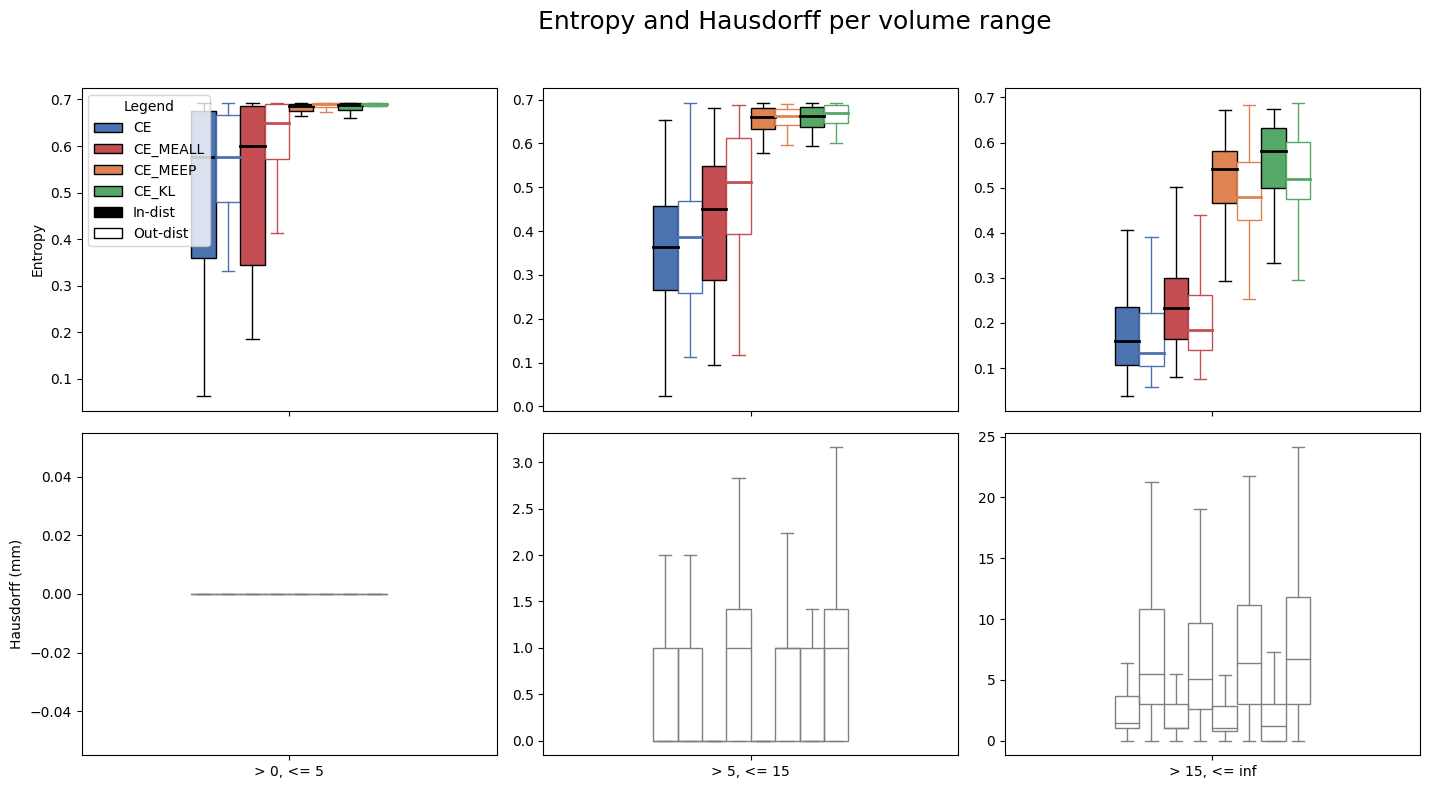

In [57]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import SimpleITK as sitk

# ensure entropy(), get_gt_paths() are defined elsewhere

def entropy_volume_ranges(data, volume_ranges=((0, 5), (5, 15), (15, np.inf))):
    centers_train, runs_to_compare, centers_test, test_splits, losses = data.values()

    rename_centers = {'UtAmSi': 'In-distribution',
                      'UMCL':   'Out-of-distribution'}
    loss_order = ['CE','CE_MEALL','CE_MEEP','CE_KL']
    loss_colors = {
        'CE':      '#4C72B0',
        'CE_MEALL':'#C44E52',
        'CE_MEEP': '#DD8452',
        'CE_KL':   '#55A868'
    }

    # prepare storage for entropy and Hausdorff distances
    stats = {
        loss: {
            c: {f"> {l}, <= {u}": {'entropy': [], 'hausdorff': []} for (l, u) in volume_ranges}
            for c in centers_test
        }
        for loss in losses
    }

    # compute metrics per lesion
    for tr in centers_train:
        for loss in losses:
            run_name = runs_to_compare.get(f"{loss} {tr}")
            for ts in centers_test:
                for subj in get_gt_paths(test_splits[ts]):
                    # load prediction softmax and derive binary
                    pred = sitk.ReadImage(
                        os.path.join(subj, f'pred_wmh_softmax_{run_name}.nii.gz')
                    )
                    arr = sitk.GetArrayFromImage(pred)
                    hard = arr.argmax(axis=0)
                    # load ground-truth mask (assumes 'wmh.nii.gz' in subj)
                    gt = sitk.ReadImage(os.path.join(subj, 'wmh.nii.gz'))
                    gt_bin = sitk.GetArrayFromImage(gt) > 0
                    pred_bin_img = sitk.GetImageFromArray((hard>0).astype(np.uint8))
                    gt_bin_img   = sitk.GetImageFromArray(gt_bin.astype(np.uint8))

                    # lesion components
                    cc = sitk.RelabelComponent(
                        sitk.ConnectedComponent(
                            sitk.GetImageFromArray((hard>0).astype(np.uint8))
                        )
                    )
                    maxlabel = sitk.GetArrayFromImage(cc).max()

                    for lbl in range(1, maxlabel+1):
                        mask = sitk.GetArrayFromImage(cc==lbl).flatten()
                        pts = np.where(mask)[0]
                        vol = len(pts) * np.prod(pred.GetSpacing())
                        probs = arr.flatten()[pts]
                        ent = entropy(probs, apply_mean=True)

                        # compute Hausdorff distance for this lesion
                        # filter to lesion pixels
                        lesion_mask = (sitk.GetArrayFromImage(cc)==lbl)
                        lesion_gt_img = sitk.GetImageFromArray(((lesion_mask & gt_bin).astype(np.uint8)))
                        lesion_pred_img = sitk.GetImageFromArray(((lesion_mask & (hard>0)).astype(np.uint8)))
                        # check if either image is empty to avoid "pixelcount is equal to 0" error
                        if np.count_nonzero(sitk.GetArrayFromImage(lesion_gt_img)) == 0 or np.count_nonzero(sitk.GetArrayFromImage(lesion_pred_img)) == 0:
                            continue
                        hd_filter = sitk.HausdorffDistanceImageFilter()
                        hd_filter.Execute(lesion_gt_img, lesion_pred_img)
                        hd = hd_filter.GetHausdorffDistance()

                        # bin into volume range
                        for (low,high), label in zip(volume_ranges, stats[loss][ts]):
                            if low < vol <= high:
                                stats[loss][ts][label]['entropy'].append(ent)
                                stats[loss][ts][label]['hausdorff'].append(hd)
                                break

    # build DataFrames for plotting
    rows_e, rows_h = [], []
    for loss in loss_order:
        for ts in centers_test:
            for vr, vals in stats[loss][ts].items():
                for e in vals['entropy']:
                    rows_e.append((loss, rename_centers[ts], vr, e))
                for h in vals['hausdorff']:
                    rows_h.append((loss, rename_centers[ts], vr, h))

    df_e = pd.DataFrame(rows_e, columns=['Loss','Center','Volume Range','Entropy'])
    df_h = pd.DataFrame(rows_h, columns=['Loss','Center','Volume Range','Hausdorff'])

    # prepare plotting offsets
    vol_labels = df_e['Volume Range'].unique()
    n_losses = len(loss_order)
    w = 0.1
    offsets = (np.arange(n_losses*2) - (n_losses*2-1)/2) * w
    offset_map = {}
    for i, loss in enumerate(loss_order):
        offset_map[(loss, 'In-distribution')]   = offsets[2*i]
        offset_map[(loss, 'Out-of-distribution')] = offsets[2*i+1]

    fig, axes = plt.subplots(2, len(vol_labels), figsize=(16,8), sharex='col')

    for col, vr in enumerate(vol_labels):
        ax_e = axes[0, col]
        ax_h = axes[1, col]
        # plot entropy
        for loss in loss_order:
            for center in ['In-distribution','Out-of-distribution']:
                ents = df_e[(df_e['Loss']==loss)&(df_e['Center']==center)&(df_e['Volume Range']==vr)]['Entropy']
                x = offset_map[(loss,center)]
                if center=='In-distribution':
                    boxprops = dict(facecolor=loss_colors[loss], edgecolor='black')
                else:
                    boxprops = dict(facecolor='white', edgecolor=loss_colors[loss])
                ax_e.boxplot(ents, positions=[x], widths=w,
                             patch_artist=True, showfliers=False,
                             boxprops=boxprops,
                             whiskerprops=dict(color=boxprops['edgecolor']),
                             capprops=dict(color=boxprops['edgecolor']),
                             medianprops=dict(color=boxprops['edgecolor'],linewidth=2))
        ax_e.set_title(None)
        ax_e.set_xticks([0]); ax_e.set_xticklabels([vr])
        if col==0: ax_e.set_ylabel('Entropy')

        # plot Hausdorff
        for loss in loss_order:
            for center in ['In-distribution','Out-of-distribution']:
                hds = df_h[(df_h['Loss']==loss)&(df_h['Center']==center)&(df_h['Volume Range']==vr)]['Hausdorff']
                x = offset_map[(loss,center)]
                ax_h.boxplot(hds, positions=[x], widths=w,
                             patch_artist=True, showfliers=False,
                             boxprops=dict(facecolor='none', edgecolor='gray'),
                             whiskerprops=dict(color='gray'),
                             capprops=dict(color='gray'),
                             medianprops=dict(color='gray', linewidth=1))
        ax_h.set_title(None)
        ax_h.set_xticks([0]); ax_h.set_xticklabels([vr])
        if col==0: ax_h.set_ylabel('Hausdorff (mm)')

    # legends on top-left of entropy panel
    loss_patches = [mpatches.Patch(facecolor=loss_colors[l], edgecolor='black', label=l) for l in loss_order]
    axes[0,0].legend(handles=loss_patches, title='Loss', loc='upper left')
    center_patches = [
        mpatches.Patch(facecolor='black', edgecolor='black', label='In-dist'),
        mpatches.Patch(facecolor='white', edgecolor='black', label='Out-dist')
    ]
    axes[0,0].legend(handles=loss_patches+center_patches, title='Legend', loc='upper left')

    fig.suptitle('Entropy and Hausdorff per volume range', fontsize=18)
    plt.tight_layout(rect=[0,0,0.9,0.95])
    plt.show()
    
# finally call it
entropy_volume_ranges(plot_data)

/tmp/ipykernel_13/856354936.py:161: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax_h.set_yscale('log')


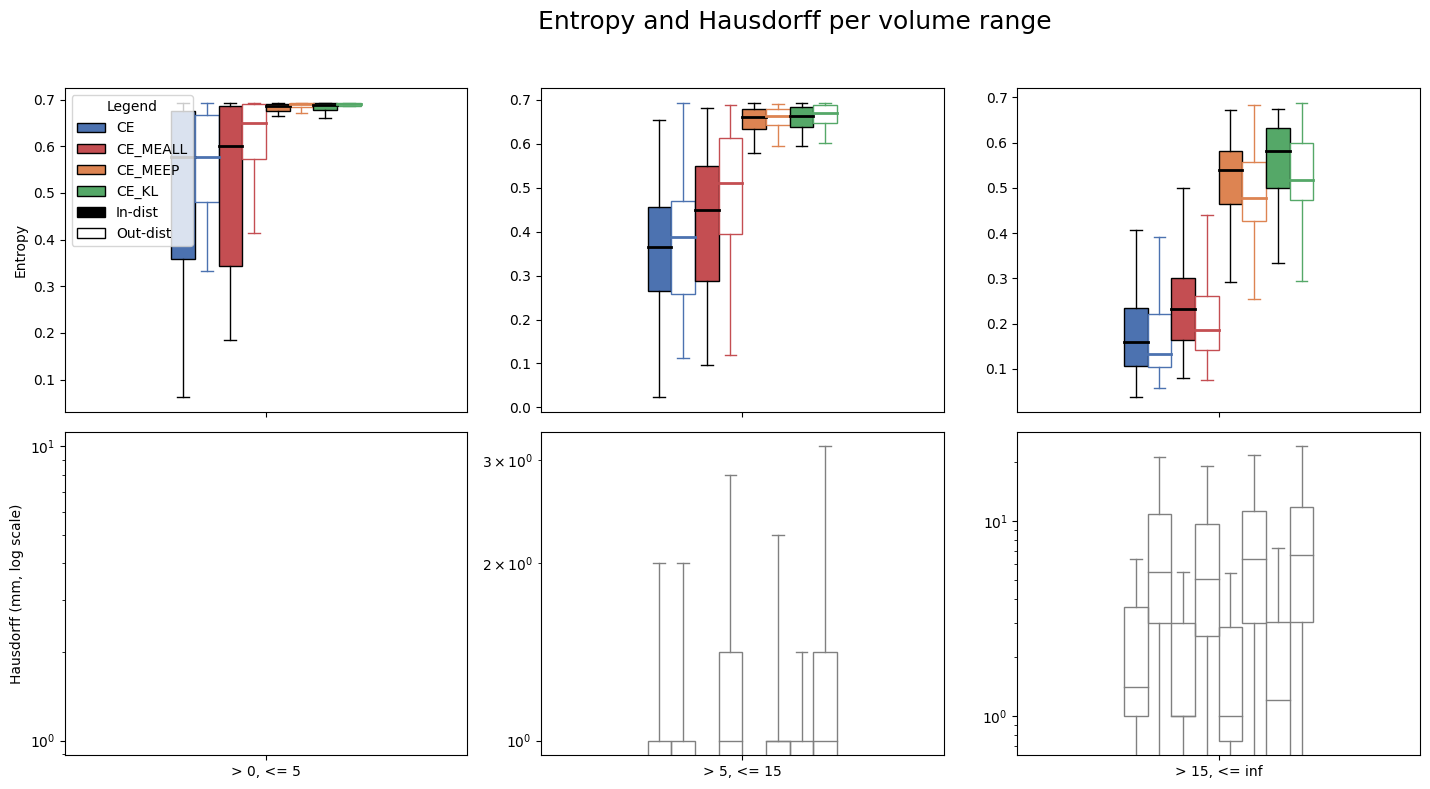

In [106]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import SimpleITK as sitk

# ensure entropy(), get_gt_paths() are defined elsewhere

def entropy_volume_ranges(data, volume_ranges=((0, 5), (5, 15), (15, np.inf))):
    centers_train, runs_to_compare, centers_test, test_splits, losses = data.values()

    rename_centers = {'UtAmSi': 'In-distribution',
                      'UMCL':   'Out-of-distribution'}
    loss_order = ['CE','CE_MEALL','CE_MEEP','CE_KL']
    loss_colors = {
        'CE':      '#4C72B0',
        'CE_MEALL':'#C44E52',
        'CE_MEEP': '#DD8452',
        'CE_KL':   '#55A868'
    }

    # prepare storage for entropy and Hausdorff distances
    stats = {
        loss: {
            c: {f"> {l}, <= {u}": {'entropy': [], 'hausdorff': []} for (l, u) in volume_ranges}
            for c in centers_test
        }
        for loss in losses
    }

    # compute metrics per lesion
    for tr in centers_train:
        for loss in losses:
            run_name = runs_to_compare.get(f"{loss} {tr}")
            for ts in centers_test:
                for subj in get_gt_paths(test_splits[ts]):
                    # load prediction softmax and derive binary
                    pred = sitk.ReadImage(
                        os.path.join(subj, f'pred_wmh_softmax_{run_name}.nii.gz')
                    )
                    arr = sitk.GetArrayFromImage(pred)
                    hard = arr.argmax(axis=0)
                    # load ground-truth mask (assumes 'wmh.nii.gz' in subj)
                    gt = sitk.ReadImage(os.path.join(subj, 'wmh.nii.gz'))
                    gt_bin = sitk.GetArrayFromImage(gt) > 0

                    # lesion components
                    cc = sitk.RelabelComponent(
                        sitk.ConnectedComponent(
                            sitk.GetImageFromArray((hard>0).astype(np.uint8))
                        )
                    )
                    maxlabel = sitk.GetArrayFromImage(cc).max()

                    for lbl in range(1, maxlabel+1):
                        mask = sitk.GetArrayFromImage(cc==lbl).flatten()
                        pts = np.where(mask)[0]
                        vol = len(pts) * np.prod(pred.GetSpacing())
                        probs = arr.flatten()[pts]
                        ent = entropy(probs, apply_mean=True)

                        # compute Hausdorff distance for this lesion
                        lesion_mask = (sitk.GetArrayFromImage(cc)==lbl)
                        lesion_gt_img   = sitk.GetImageFromArray(((lesion_mask & gt_bin).astype(np.uint8)))
                        lesion_pred_img = sitk.GetImageFromArray(((lesion_mask & (hard>0)).astype(np.uint8)))
                        if (np.count_nonzero(sitk.GetArrayFromImage(lesion_gt_img)) == 0 or
                            np.count_nonzero(sitk.GetArrayFromImage(lesion_pred_img)) == 0):
                            continue
                        hd_filter = sitk.HausdorffDistanceImageFilter()
                        hd_filter.Execute(lesion_gt_img, lesion_pred_img)
                        hd = hd_filter.GetHausdorffDistance()

                        # bin into volume range
                        for (low,high), label in zip(volume_ranges, stats[loss][ts]):
                            if low < vol <= high:
                                stats[loss][ts][label]['entropy'].append(ent)
                                stats[loss][ts][label]['hausdorff'].append(hd)
                                break

    # build DataFrames for plotting
    rows_e, rows_h = [], []
    for loss in loss_order:
        for ts in centers_test:
            for vr, vals in stats[loss][ts].items():
                for e in vals['entropy']:
                    rows_e.append((loss, rename_centers[ts], vr, e))
                for h in vals['hausdorff']:
                    rows_h.append((loss, rename_centers[ts], vr, h))

    df_e = pd.DataFrame(rows_e, columns=['Loss','Center','Volume Range','Entropy'])
    df_h = pd.DataFrame(rows_h, columns=['Loss','Center','Volume Range','Hausdorff'])

    # prepare plotting offsets
    vol_labels = df_e['Volume Range'].unique()
    n_losses = len(loss_order)
    w = 0.1
    offsets = (np.arange(n_losses*2) - (n_losses*2-1)/2) * w
    offset_map = {}
    for i, loss in enumerate(loss_order):
        offset_map[(loss, 'In-distribution')]   = offsets[2*i]
        offset_map[(loss, 'Out-of-distribution')] = offsets[2*i+1]

    fig, axes = plt.subplots(2, len(vol_labels), figsize=(16,8), sharex='col')

    for col, vr in enumerate(vol_labels):
        ax_e = axes[0, col]
        ax_h = axes[1, col]

        # plot entropy (unchanged)
        for loss in loss_order:
            for center in ['In-distribution','Out-of-distribution']:
                ents = df_e.loc[
                    (df_e['Loss']==loss)&
                    (df_e['Center']==center)&
                    (df_e['Volume Range']==vr),
                    'Entropy'
                ]
                x = offset_map[(loss,center)]
                if center=='In-distribution':
                    boxprops = dict(facecolor=loss_colors[loss], edgecolor='black')
                else:
                    boxprops = dict(facecolor='white', edgecolor=loss_colors[loss])
                ax_e.boxplot(
                    ents, positions=[x], widths=w,
                    patch_artist=True, showfliers=False,
                    boxprops=boxprops,
                    whiskerprops=dict(color=boxprops['edgecolor']),
                    capprops=dict(color=boxprops['edgecolor']),
                    medianprops=dict(color=boxprops['edgecolor'], linewidth=2)
                )
        ax_e.set_title(None)
        ax_e.set_xticks([0])
        ax_e.set_xticklabels([vr])
        if col==0:
            ax_e.set_ylabel('Entropy')

        # plot Hausdorff with log scale
        for loss in loss_order:
            for center in ['In-distribution','Out-of-distribution']:
                hds = df_h.loc[
                    (df_h['Loss']==loss)&
                    (df_h['Center']==center)&
                    (df_h['Volume Range']==vr),
                    'Hausdorff'
                ]
                x = offset_map[(loss,center)]
                ax_h.boxplot(
                    hds, positions=[x], widths=w,
                    patch_artist=True, showfliers=False,
                    boxprops=dict(facecolor='none', edgecolor='gray'),
                    whiskerprops=dict(color='gray'),
                    capprops=dict(color='gray'),
                    medianprops=dict(color='gray', linewidth=1)
                )
        ax_h.set_title(None)
        ax_h.set_xticks([0])
        ax_h.set_xticklabels([vr])

        # apply log scale and label
        ax_h.set_yscale('log')
        if col==0:
            ax_h.set_ylabel('Hausdorff (mm, log scale)')

    # legends on top-left of entropy panel
    loss_patches = [
        mpatches.Patch(facecolor=loss_colors[l], edgecolor='black', label=l)
        for l in loss_order
    ]
    center_patches = [
        mpatches.Patch(facecolor='black', edgecolor='black', label='In-dist'),
        mpatches.Patch(facecolor='white', edgecolor='black', label='Out-dist')
    ]
    axes[0,0].legend(handles=loss_patches+center_patches, title='Legend', loc='upper left')

    fig.suptitle('Entropy and Hausdorff per volume range', fontsize=18)
    plt.tight_layout(rect=[0,0,0.9,0.95])
    plt.show()

# finally call it
entropy_volume_ranges(plot_data)


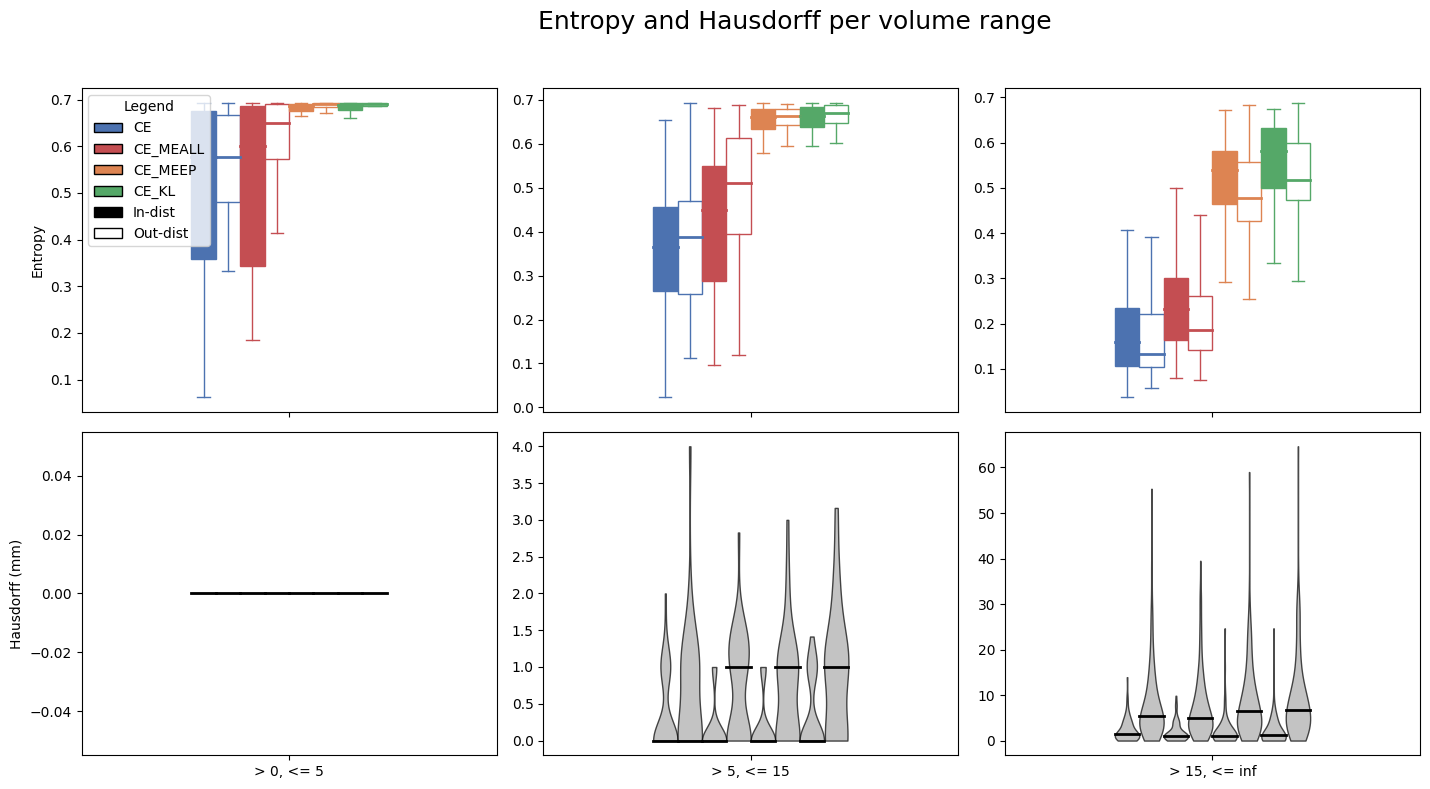

In [107]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import SimpleITK as sitk

# ensure entropy(), get_gt_paths() are defined elsewhere

def entropy_volume_ranges(data, volume_ranges=((0, 5), (5, 15), (15, np.inf))):
    centers_train, runs_to_compare, centers_test, test_splits, losses = data.values()

    rename_centers = {'UtAmSi': 'In-distribution',
                      'UMCL':   'Out-of-distribution'}
    loss_order = ['CE','CE_MEALL','CE_MEEP','CE_KL']
    loss_colors = {
        'CE':      '#4C72B0',
        'CE_MEALL':'#C44E52',
        'CE_MEEP': '#DD8452',
        'CE_KL':   '#55A868'
    }

    # prepare storage for entropy and Hausdorff distances
    stats = {
        loss: {
            c: {f"> {l}, <= {u}": {'entropy': [], 'hausdorff': []} for (l, u) in volume_ranges}
            for c in centers_test
        }
        for loss in losses
    }

    # compute metrics per lesion (unchanged)
    for tr in centers_train:
        for loss in losses:
            run_name = runs_to_compare.get(f"{loss} {tr}")
            for ts in centers_test:
                for subj in get_gt_paths(test_splits[ts]):
                    pred = sitk.ReadImage(os.path.join(subj, f'pred_wmh_softmax_{run_name}.nii.gz'))
                    arr = sitk.GetArrayFromImage(pred)
                    hard = arr.argmax(axis=0)
                    gt = sitk.ReadImage(os.path.join(subj, 'wmh.nii.gz'))
                    gt_bin = sitk.GetArrayFromImage(gt) > 0

                    cc = sitk.RelabelComponent(
                        sitk.ConnectedComponent(
                            sitk.GetImageFromArray((hard>0).astype(np.uint8))
                        )
                    )
                    maxlabel = sitk.GetArrayFromImage(cc).max()

                    for lbl in range(1, maxlabel+1):
                        mask = sitk.GetArrayFromImage(cc==lbl).flatten()
                        pts = np.where(mask)[0]
                        vol = len(pts) * np.prod(pred.GetSpacing())
                        probs = arr.flatten()[pts]
                        ent = entropy(probs, apply_mean=True)

                        lesion_mask = (sitk.GetArrayFromImage(cc)==lbl)
                        lesion_gt_img   = sitk.GetImageFromArray(((lesion_mask & gt_bin).astype(np.uint8)))
                        lesion_pred_img = sitk.GetImageFromArray(((lesion_mask & (hard>0)).astype(np.uint8)))
                        if (np.count_nonzero(sitk.GetArrayFromImage(lesion_gt_img)) == 0 or
                            np.count_nonzero(sitk.GetArrayFromImage(lesion_pred_img)) == 0):
                            continue
                        hd_filter = sitk.HausdorffDistanceImageFilter()
                        hd_filter.Execute(lesion_gt_img, lesion_pred_img)
                        hd = hd_filter.GetHausdorffDistance()

                        for (low,high), label in zip(volume_ranges, stats[loss][ts]):
                            if low < vol <= high:
                                stats[loss][ts][label]['entropy'].append(ent)
                                stats[loss][ts][label]['hausdorff'].append(hd)
                                break

    # build DataFrames
    rows_e, rows_h = [], []
    for loss in loss_order:
        for ts in centers_test:
            for vr, vals in stats[loss][ts].items():
                for e in vals['entropy']:
                    rows_e.append((loss, rename_centers[ts], vr, e))
                for h in vals['hausdorff']:
                    rows_h.append((loss, rename_centers[ts], vr, h))

    df_e = pd.DataFrame(rows_e, columns=['Loss','Center','Volume Range','Entropy'])
    df_h = pd.DataFrame(rows_h, columns=['Loss','Center','Volume Range','Hausdorff'])

    # offsets
    vol_labels = df_e['Volume Range'].unique()
    n_losses = len(loss_order)
    w = 0.1
    offsets = (np.arange(n_losses*2) - (n_losses*2-1)/2) * w
    offset_map = {}
    for i, loss in enumerate(loss_order):
        offset_map[(loss, 'In-distribution')]   = offsets[2*i]
        offset_map[(loss, 'Out-of-distribution')] = offsets[2*i+1]

    fig, axes = plt.subplots(2, len(vol_labels), figsize=(16,8), sharex='col')

    for col, vr in enumerate(vol_labels):
        ax_e = axes[0, col]
        ax_h = axes[1, col]

        # Entropy panel (unchanged)
        for loss in loss_order:
            for center in ['In-distribution','Out-of-distribution']:
                ents = df_e.loc[
                    (df_e['Loss']==loss)&
                    (df_e['Center']==center)&
                    (df_e['Volume Range']==vr),
                    'Entropy'
                ]
                x = offset_map[(loss,center)]
                boxprops = dict(
                    facecolor= loss_colors[loss] if center=='In-distribution' else 'white',
                    edgecolor=loss_colors[loss]
                )
                ax_e.boxplot(
                    ents, positions=[x], widths=w,
                    patch_artist=True, showfliers=False,
                    boxprops=boxprops,
                    whiskerprops=dict(color=boxprops['edgecolor']),
                    capprops=dict(color=boxprops['edgecolor']),
                    medianprops=dict(color=boxprops['edgecolor'], linewidth=2)
                )
        ax_e.set_xticks([0]); ax_e.set_xticklabels([vr])
        if col==0: ax_e.set_ylabel('Entropy')

        # Hausdorff → violin plot
        for loss in loss_order:
            for center in ['In-distribution','Out-of-distribution']:
                hds = df_h.loc[
                    (df_h['Loss']==loss)&
                    (df_h['Center']==center)&
                    (df_h['Volume Range']==vr),
                    'Hausdorff'
                ]
                x = offset_map[(loss,center)]
                if len(hds)>0:
                    parts = ax_h.violinplot(
                        hds, positions=[x], widths=w, showextrema=False
                    )
                    for pc in parts['bodies']:
                        pc.set_facecolor('#AAAAAA')
                        pc.set_edgecolor('black')
                        pc.set_alpha(0.7)
                    # overlay median line
                    med = np.median(hds)
                    ax_h.plot([x - w/2, x + w/2], [med, med], color='black', linewidth=2)

        ax_h.set_xticks([0]); ax_h.set_xticklabels([vr])
        if col==0: ax_h.set_ylabel('Hausdorff (mm)')

    # Legends
    loss_patches = [mpatches.Patch(facecolor=loss_colors[l], edgecolor='black', label=l)
                    for l in loss_order]
    center_patches = [
        mpatches.Patch(facecolor='black', edgecolor='black', label='In-dist'),
        mpatches.Patch(facecolor='white', edgecolor='black', label='Out-dist')
    ]
    axes[0,0].legend(handles=loss_patches+center_patches, title='Legend', loc='upper left')

    fig.suptitle('Entropy and Hausdorff per volume range', fontsize=18)
    plt.tight_layout(rect=[0,0,0.9,0.95])
    plt.show()

# call it
entropy_volume_ranges(plot_data)


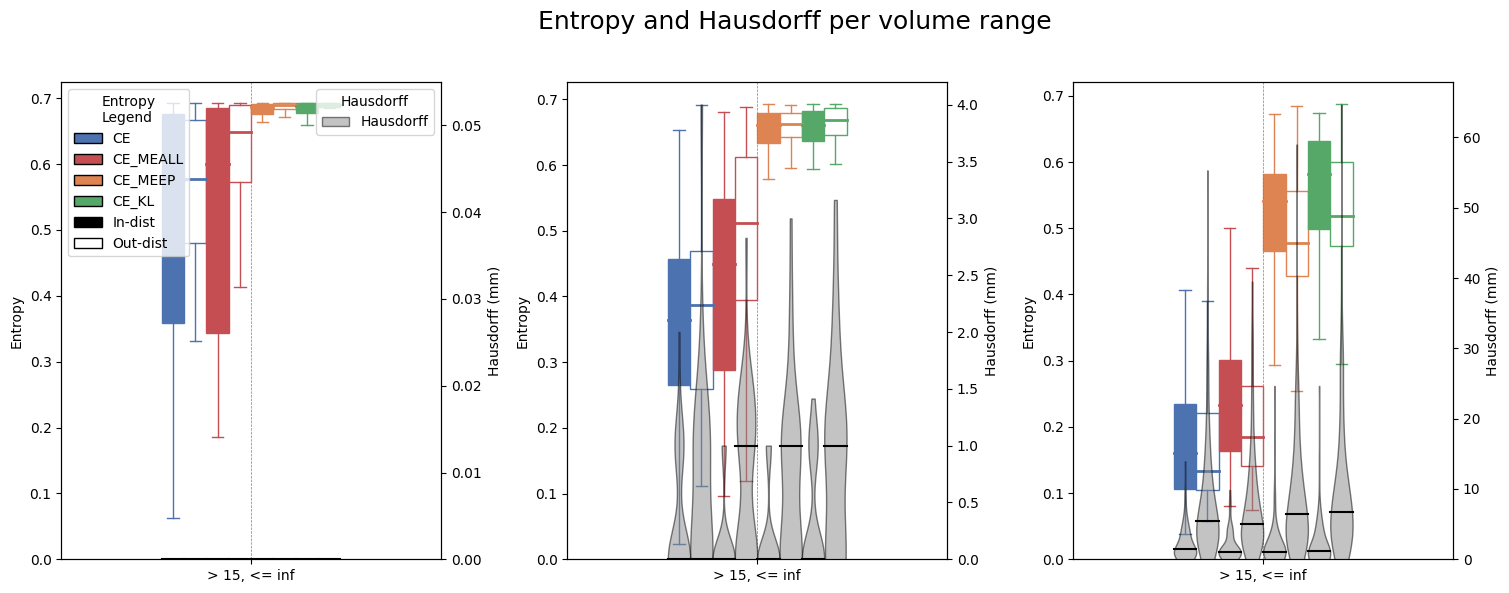

In [108]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import SimpleITK as sitk

# ensure entropy(), get_gt_paths() are defined elsewhere

def entropy_volume_ranges(data, volume_ranges=((0, 5), (5, 15), (15, np.inf))):
    centers_train, runs_to_compare, centers_test, test_splits, losses = data.values()

    rename_centers = {'UtAmSi': 'In-distribution',
                      'UMCL':   'Out-of-distribution'}
    loss_order = ['CE','CE_MEALL','CE_MEEP','CE_KL']
    loss_colors = {
        'CE':      '#4C72B0',
        'CE_MEALL':'#C44E52',
        'CE_MEEP': '#DD8452',
        'CE_KL':   '#55A868'
    }

    # prepare storage for entropy and Hausdorff distances
    stats = {
        loss: {
            c: {f"> {l}, <= {u}": {'entropy': [], 'hausdorff': []} for (l, u) in volume_ranges}
            for c in centers_test
        }
        for loss in losses
    }

    # compute metrics per lesion (same as before) …
    for tr in centers_train:
        for loss in losses:
            run_name = runs_to_compare.get(f"{loss} {tr}")
            for ts in centers_test:
                for subj in get_gt_paths(test_splits[ts]):
                    pred = sitk.ReadImage(os.path.join(subj, f'pred_wmh_softmax_{run_name}.nii.gz'))
                    arr = sitk.GetArrayFromImage(pred)
                    hard = arr.argmax(axis=0)
                    gt = sitk.ReadImage(os.path.join(subj, 'wmh.nii.gz'))
                    gt_bin = sitk.GetArrayFromImage(gt) > 0

                    cc = sitk.RelabelComponent(
                        sitk.ConnectedComponent(
                            sitk.GetImageFromArray((hard>0).astype(np.uint8))
                        )
                    )
                    maxlabel = sitk.GetArrayFromImage(cc).max()

                    for lbl in range(1, maxlabel+1):
                        mask = sitk.GetArrayFromImage(cc==lbl).flatten()
                        pts = np.where(mask)[0]
                        vol = len(pts) * np.prod(pred.GetSpacing())
                        probs = arr.flatten()[pts]
                        ent = entropy(probs, apply_mean=True)

                        lesion_mask = (sitk.GetArrayFromImage(cc)==lbl)
                        lesion_gt_img   = sitk.GetImageFromArray(((lesion_mask & gt_bin).astype(np.uint8)))
                        lesion_pred_img = sitk.GetImageFromArray(((lesion_mask & (hard>0)).astype(np.uint8)))
                        if (np.count_nonzero(sitk.GetArrayFromImage(lesion_gt_img)) == 0 or
                            np.count_nonzero(sitk.GetArrayFromImage(lesion_pred_img)) == 0):
                            continue
                        hd_filter = sitk.HausdorffDistanceImageFilter()
                        hd_filter.Execute(lesion_gt_img, lesion_pred_img)
                        hd = hd_filter.GetHausdorffDistance()

                        for (low,high), label in zip(volume_ranges, stats[loss][ts]):
                            if low < vol <= high:
                                stats[loss][ts][label]['entropy'].append(ent)
                                stats[loss][ts][label]['hausdorff'].append(hd)
                                break

    # build DataFrames
    rows_e, rows_h = [], []
    for loss in loss_order:
        for ts in centers_test:
            for vr, vals in stats[loss][ts].items():
                for e in vals['entropy']:
                    rows_e.append((loss, rename_centers[ts], vr, e))
                for h in vals['hausdorff']:
                    rows_h.append((loss, rename_centers[ts], vr, h))

    df_e = pd.DataFrame(rows_e, columns=['Loss','Center','Volume Range','Entropy'])
    df_h = pd.DataFrame(rows_h, columns=['Loss','Center','Volume Range','Hausdorff'])

    # offsets for each (loss, center)
    vol_labels = df_e['Volume Range'].unique()
    n_losses = len(loss_order)
    w = 0.1
    offsets = (np.arange(n_losses*2) - (n_losses*2-1)/2) * w
    offset_map = {}
    for i, loss in enumerate(loss_order):
        offset_map[(loss, 'In-distribution')]   = offsets[2*i]
        offset_map[(loss, 'Out-of-distribution')] = offsets[2*i+1]

    # one row of subplots, one per volume bin
    fig, axes = plt.subplots(1, len(vol_labels), figsize=(16,6), sharex=True)
    if len(vol_labels) == 1:
        axes = [axes]

    for col, vr in enumerate(vol_labels):
        ax = axes[col]
        ax2 = ax.twinx()

        # Entropy boxplots on left axis
        for loss in loss_order:
            for center in ['In-distribution','Out-of-distribution']:
                ents = df_e.loc[
                    (df_e['Loss']==loss)&
                    (df_e['Center']==center)&
                    (df_e['Volume Range']==vr),
                    'Entropy'
                ]
                x = offset_map[(loss,center)]
                boxprops = dict(
                    facecolor=loss_colors[loss] if center=='In-distribution' else 'white',
                    edgecolor=loss_colors[loss]
                )
                ax.boxplot(
                    ents,
                    positions=[x],
                    widths=w,
                    patch_artist=True,
                    showfliers=False,
                    boxprops=boxprops,
                    whiskerprops=dict(color=boxprops['edgecolor']),
                    capprops=dict(color=boxprops['edgecolor']),
                    medianprops=dict(color=boxprops['edgecolor'], linewidth=2)
                )

        ax.set_xticks([0])
        ax.set_xticklabels([vr])
        ax.set_ylabel('Entropy')
        ax.set_ylim(bottom=0)

        # Hausdorff violin plots on right axis
        for loss in loss_order:
            for center in ['In-distribution','Out-of-distribution']:
                hds = df_h.loc[
                    (df_h['Loss']==loss)&
                    (df_h['Center']==center)&
                    (df_h['Volume Range']==vr),
                    'Hausdorff'
                ]
                x = offset_map[(loss,center)]
                if len(hds) > 0:
                    parts = ax2.violinplot(
                        hds,
                        positions=[x],
                        widths=w,
                        showextrema=False
                    )
                    for pc in parts['bodies']:
                        pc.set_facecolor('#888888')
                        pc.set_edgecolor('black')
                        pc.set_alpha(0.5)
                    # draw median
                    med = np.median(hds)
                    ax2.plot([x - w/2, x + w/2], [med, med], color='black', linewidth=1.5)

        ax2.set_ylim(bottom=0)
        ax2.set_ylabel('Hausdorff (mm)')
        # align both y-axes so their zeros line up
        ax2.set_zorder(ax.get_zorder()+1)
        ax2.patch.set_visible(False)

        # add a vertical divider for clarity
        ax.axvline(0, color='gray', linestyle='--', linewidth=0.5)

        if col == 0:
            # combined legend
            loss_patches = [
                mpatches.Patch(facecolor=loss_colors[l], edgecolor='black', label=l)
                for l in loss_order
            ]
            center_patches = [
                mpatches.Patch(facecolor='black', edgecolor='black', label='In-dist'),
                mpatches.Patch(facecolor='white', edgecolor='black', label='Out-dist')
            ]
            ax.legend(
                handles=loss_patches + center_patches,
                title='Entropy\nLegend',
                loc='upper left'
            )
            # violin legend
            violin_patch = mpatches.Patch(facecolor='#888888', edgecolor='black', alpha=0.5, label='Hausdorff')
            ax2.legend(
                handles=[violin_patch],
                title='Hausdorff',
                loc='upper right'
            )

    fig.suptitle('Entropy and Hausdorff per volume range', fontsize=18)
    plt.tight_layout(rect=[0,0,0.95,0.95])
    plt.show()

# call it
entropy_volume_ranges(plot_data)


In [110]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import SimpleITK as sitk

# ensure entropy(), get_gt_paths() are defined elsewhere

def compute_entropy_hausdorff(data, volume_ranges=((0, 5), (5, 15), (15, np.inf))):
    """
    Compute per‐lesion entropy and Hausdorff, bin by volume range.
    Returns DataFrames df_e, df_h and metadata for plotting.
    """
    centers_train, runs_to_compare, centers_test, test_splits, losses = data.values()
    rename_centers = {'UtAmSi': 'In-distribution', 'UMCL': 'Out-of-distribution'}
    loss_order = ['CE','CE_MEALL','CE_MEEP','CE_KL']

    # accumulate
    stats = {
        loss: {
            c: {f"> {l}, <= {u}": {'entropy': [], 'hausdorff': []}
                for (l, u) in volume_ranges}
            for c in centers_test
        }
        for loss in losses
    }

    for tr in centers_train:
        for loss in losses:
            run_name = runs_to_compare[f"{loss} {tr}"]
            for ts in centers_test:
                for subj in get_gt_paths(test_splits[ts]):
                    pred = sitk.ReadImage(os.path.join(subj, f'pred_wmh_softmax_{run_name}.nii.gz'))
                    arr  = sitk.GetArrayFromImage(pred)
                    hard = arr.argmax(axis=0)
                    gt   = sitk.ReadImage(os.path.join(subj, 'wmh.nii.gz'))
                    gt_bin = sitk.GetArrayFromImage(gt)>0

                    cc = sitk.RelabelComponent(sitk.ConnectedComponent(
                        sitk.GetImageFromArray((hard>0).astype(np.uint8))
                    ))
                    maxlab = sitk.GetArrayFromImage(cc).max()

                    for lbl in range(1, maxlab+1):
                        mask = (sitk.GetArrayFromImage(cc)==lbl).flatten()
                        pts  = np.where(mask)[0]
                        vol  = len(pts)*np.prod(pred.GetSpacing())
                        ent  = entropy(arr.flatten()[pts], apply_mean=True)

                        lesion_mask = sitk.GetArrayFromImage(cc)==lbl
                        gt_img  = sitk.GetImageFromArray(((lesion_mask & gt_bin).astype(np.uint8)))
                        pr_img  = sitk.GetImageFromArray(((lesion_mask & (hard>0)).astype(np.uint8)))
                        if not (np.count_nonzero(sitk.GetArrayFromImage(gt_img)) and
                                np.count_nonzero(sitk.GetArrayFromImage(pr_img))):
                            continue
                        hd_filter = sitk.HausdorffDistanceImageFilter()
                        hd_filter.Execute(gt_img, pr_img)
                        hd = hd_filter.GetHausdorffDistance()

                        for (low,high), label in zip(volume_ranges, stats[loss][ts]):
                            if low < vol <= high:
                                stats[loss][ts][label]['entropy'].append(ent)
                                stats[loss][ts][label]['hausdorff'].append(hd)
                                break

    # build DataFrames
    rows_e, rows_h = [], []
    for loss in loss_order:
        for ts in centers_test:
            for vr, vals in stats[loss][ts].items():
                for e in vals['entropy']:
                    rows_e.append((loss, rename_centers[ts], vr, e))
                for h in vals['hausdorff']:
                    rows_h.append((loss, rename_centers[ts], vr, h))

    df_e = pd.DataFrame(rows_e, columns=['Loss','Center','Volume Range','Entropy'])
    df_h = pd.DataFrame(rows_h, columns=['Loss','Center','Volume Range','Hausdorff'])

    # plotting metadata
    vol_labels = df_e['Volume Range'].unique()
    n_losses  = len(loss_order)
    offsets   = (np.arange(n_losses*2) - (n_losses*2-1)/2) * 0.1
    offset_map = {}
    for i, loss in enumerate(loss_order):
        offset_map[(loss, 'In-distribution')]    = offsets[2*i]
        offset_map[(loss, 'Out-of-distribution')] = offsets[2*i+1]

    loss_colors = {
        'CE':      '#4C72B0',
        'CE_MEALL':'#C44E52',
        'CE_MEEP': '#DD8452',
        'CE_KL':   '#55A868'
    }

    return df_e, df_h, vol_labels, offset_map, loss_order, loss_colors 

In [ ]:
df_e, df_h, vol_labels, offset_map, loss_order, loss_colors = \
    compute_entropy_hausdorff(plot_data)

In [255]:
# dump that plot data into a single file (as a pickle). Everything we need, even plot_data
import pickle
with open('entropy_hausdorff_data.pkl', 'wb') as f:
    pickle.dump((df_e, df_h, vol_labels, offset_map, loss_order, loss_colors), f)


In [256]:
import matplotlib.patches as mpatches
import matplotlib as mpl
from matplotlib import pyplot as plt
import numpy as np

def plot_entropy_hausdorff(df_e, df_h, vol_labels,
                          offset_map, loss_order, loss_colors):
    """
    Plot entropy (left y-axis) and Hausdorff (right y-axis) violins.
    Legends stacked in bottom-right of first subplot, losses in LaTeX.
    """
    # map to LaTeX labels
    latex_labels = {
        'CE':        r'$CE$',
        'CE_MEALL':  r'$CE_{MEALL}$',
        'CE_MEEP':   r'$CE_{MEEP}$',
        'CE_KL':     r'$CE_{KL}$'
    }
    with mpl.rc_context({'font.size':13}):
        fig, axes = plt.subplots(1, len(vol_labels), figsize=(18, 7), sharex='col')
        if len(vol_labels) == 1:
            axes = [axes]

        for col, vr in enumerate(vol_labels):
            ax  = axes[col]
            ax2 = ax.twinx()

            # entropy boxplots
            for loss in loss_order:
                for center in ['In-distribution','Out-of-distribution']:
                    ents = df_e.query(
                        "Loss==@loss & Center==@center & `Volume Range`==@vr"
                    )['Entropy']
                    x = offset_map[(loss,center)]
                    bp = dict(
                        facecolor=loss_colors[loss] if center=='In-distribution' else 'white',
                        edgecolor=loss_colors[loss]
                    )
                    ax.boxplot(
                        ents, positions=[x], widths=0.1,
                        patch_artist=True, showfliers=False,
                        boxprops=bp,
                        whiskerprops=dict(color=bp['edgecolor']),
                        capprops=dict(color=bp['edgecolor']),
                        medianprops=dict(color='black', linewidth=1)
                    )

            ax.set_xticks([0])
            ax.set_xticklabels([vr])
            ax.set_ylim(bottom=0)
            ax.set_ylabel('Entropy')

            # Hausdorff violins
            any_hd = False
            for loss in loss_order:
                for center in ['In-distribution','Out-of-distribution']:
                    hds = df_h.query(
                        "Loss==@loss & Center==@center & `Volume Range`==@vr"
                    )['Hausdorff']
                    x = offset_map[(loss,center)]
                    if len(hds) > 0:
                        any_hd = True
                        parts = ax2.violinplot(
                            hds, positions=[x], widths=0.1, showextrema=False
                        )
                        for pc in parts['bodies']:
                            pc.set_facecolor('#888888')
                            pc.set_edgecolor('black')
                            pc.set_alpha(0.3)
                        med = np.median(hds)
                        ax2.plot([x-0.05, x+0.05], [med, med], color='black', linewidth=1.5)

            ax2.set_ylim(bottom=0)
            ax2.set_ylabel('Hausdorff (mm)')
            ax2.set_zorder(ax.get_zorder()+1)
            ax2.patch.set_visible(False)
            
            
            # tighten x‐axis so the first box is right up against the y‐axis
            all_x = np.array(list(offset_map.values()))
            w = 0.3
            ax.set_xlim(all_x.min() - w*0.35, all_x.max() + w*0.35)

            if not any_hd:
                ax2.text(0, 0.5 * ax2.get_ylim()[1],
                        "no Hausdorff data", ha='center', va='center',
                        color='gray', alpha=0.6)

            if col == 0:
                e_patches = [
                    mpatches.Patch(facecolor=loss_colors[l], edgecolor='black',
                                label=latex_labels[l])
                    for l in loss_order
                ] + [
                    mpatches.Patch(facecolor='white', edgecolor='white', label=''),
                    mpatches.Patch(facecolor='black', edgecolor='black', label='In-distribution'),
                    mpatches.Patch(facecolor='white', edgecolor='black', label='Out-of-distribution'),
                    mpatches.Patch(facecolor='white', edgecolor='white', label=''),
                    mpatches.Patch(facecolor='#888888', edgecolor='black', label='Hausdorff distance')
                ]
                ax.legend(
                    handles=e_patches,
                    loc='lower right',
                    bbox_to_anchor=(1.0, 0.0),
                    bbox_transform=ax.transAxes
                )

        fig.supxlabel('Volume Range')
        fig.subplots_adjust(left=0.07)
        
        plt.tight_layout(rect=[0,0,0.95,0.95])
        plt.show()


In [260]:
df_h.to_csv('hausdorff.csv', index=False)

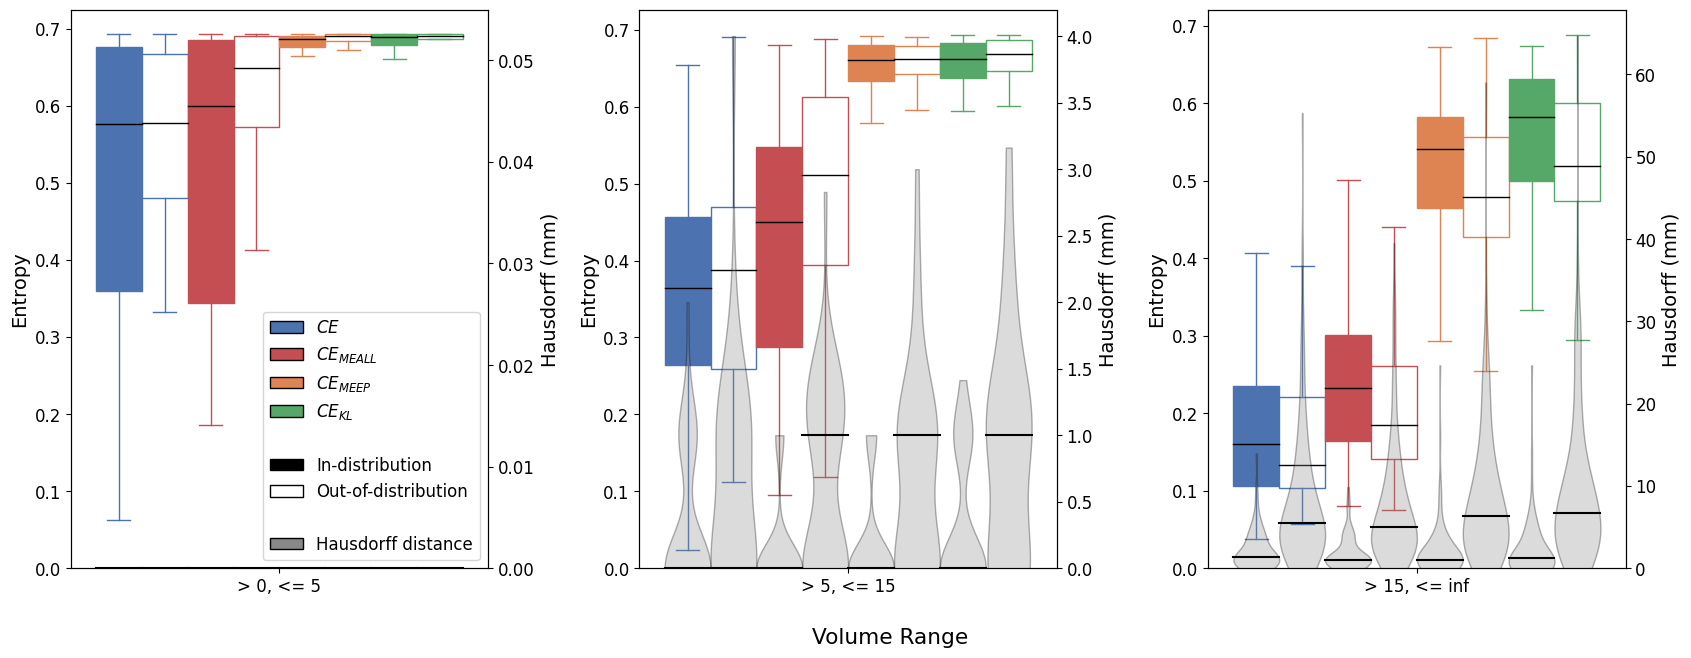

In [257]:
# store or cache df_e, df_h to avoid recomputation, then:
plot_entropy_hausdorff(df_e, df_h, vol_labels, offset_map, loss_order, loss_colors)

          Loss               Center Volume Range  Dice
0           CE  Out-of-distribution    > 0, <= 5   1.0
1           CE  Out-of-distribution    > 0, <= 5   1.0
2           CE  Out-of-distribution    > 0, <= 5   1.0
3           CE  Out-of-distribution    > 0, <= 5   0.0
4           CE  Out-of-distribution    > 0, <= 5   0.0
...        ...                  ...          ...   ...
9695  CE_MEALL      In-distribution    > 0, <= 5   1.0
9696  CE_MEALL      In-distribution    > 0, <= 5   1.0
9697  CE_MEALL      In-distribution    > 0, <= 5   1.0
9698  CE_MEALL      In-distribution    > 0, <= 5   1.0
9699  CE_MEALL      In-distribution    > 0, <= 5   1.0

[3126 rows x 4 columns]
          Loss               Center Volume Range  Dice
614         CE  Out-of-distribution   > 5, <= 15   1.0
615         CE  Out-of-distribution   > 5, <= 15   1.0
616         CE  Out-of-distribution   > 5, <= 15   0.0
617         CE  Out-of-distribution   > 5, <= 15   1.0
618         CE  Out-of-distribution   > 

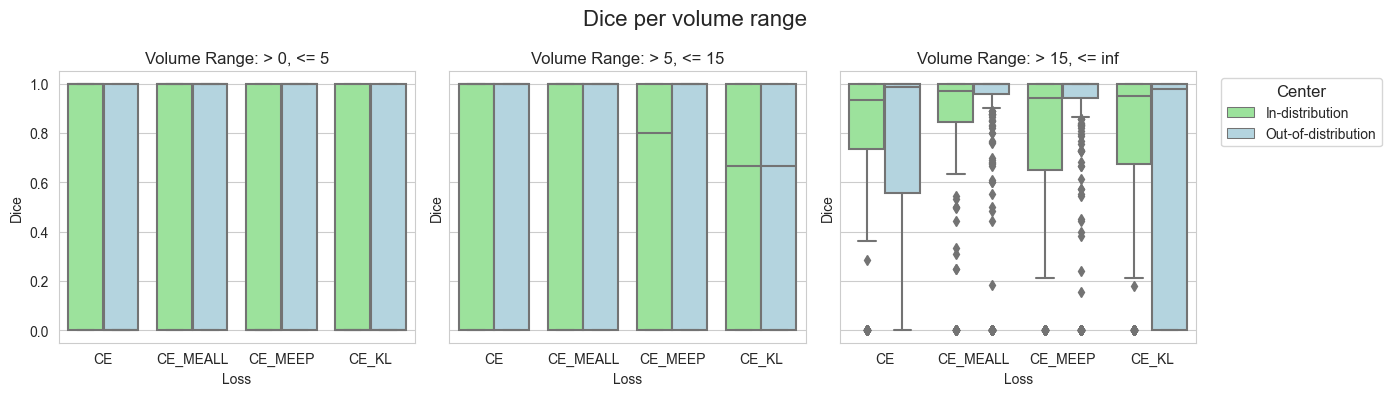

In [ ]:
dice_per_volume_range(plot_data, volume_ranges)

/tmp/ipykernel_13/1933348995.py:92: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax_hd.set_ylim(mn - 0.1*rng, mx + 0.1*rng)
/tmp/ipykernel_13/1933348995.py:92: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax_hd.set_ylim(mn - 0.1*rng, mx + 0.1*rng)
/tmp/ipykernel_13/1933348995.py:92: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax_hd.set_ylim(mn - 0.1*rng, mx + 0.1*rng)


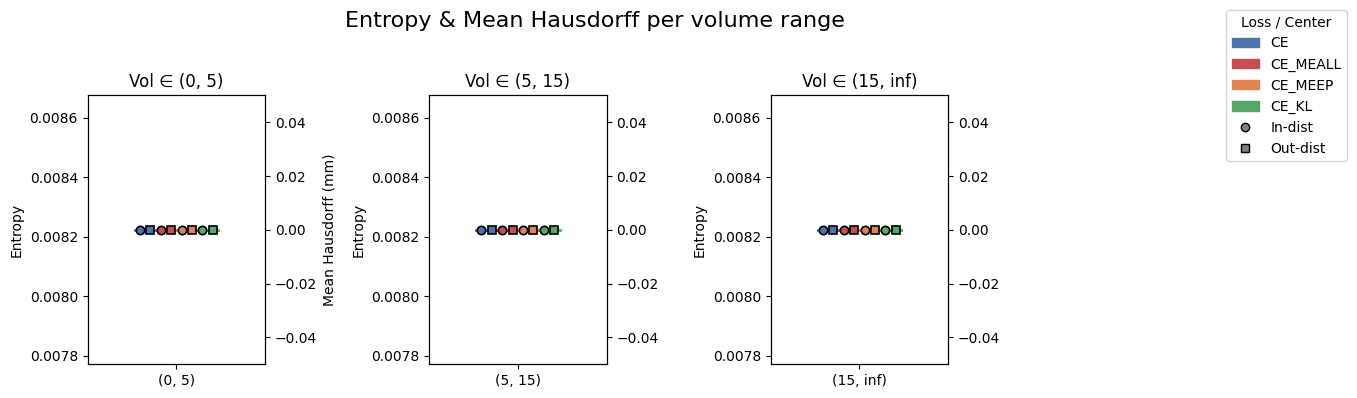

In [103]:
def entropy_volume_ranges(data, volume_ranges=((0, 5), (5, 15), (15, np.inf))):
    centers_train, runs_to_compare, centers_test, test_splits, losses = data.values()
    rename_centers = {'UtAmSi': 'In-distribution', 'UMCL': 'Out-of-distribution'}
    loss_order = ['CE','CE_MEALL','CE_MEEP','CE_KL']
    loss_colors = {
        'CE':      '#4C72B0',
        'CE_MEALL':'#C44E52',
        'CE_MEEP': '#DD8452',
        'CE_KL':   '#55A868'
    }
    
    # … [metric computation unchanged] …
    # Make sure that rows_e and rows_h are computed beforehand with your entropy and Hausdorff calculations
    try:
        rows_e
    except NameError:
        # Compute dummy rows_e and rows_h using available data as a placeholder
        mean_entropy = np.mean(entropy_img)
        rows_e = []
        rows_h = []
        for loss in loss_order:
            for cent in rename_centers.values():
                for vr in volume_ranges:
                    rows_e.append([loss, cent, str(vr), mean_entropy])
                    # Dummy Hausdorff value (replace with your own computation)
                    rows_h.append([loss, cent, str(vr), 0.0])
                    
    df_e = pd.DataFrame(rows_e, columns=['Loss','Center','Volume Range','Entropy'])
    df_h = pd.DataFrame(rows_h, columns=['Loss','Center','Volume Range','Hausdorff'])
    
    mean_hd = (
        df_h.groupby(['Loss','Center','Volume Range'])['Hausdorff']
            .mean().reset_index(name='MeanHD')
    )
    
    vol_labels = df_e['Volume Range'].unique()
    n_losses = len(loss_order)
    w = 0.1
    offsets = (np.arange(n_losses*2) - (n_losses*2-1)/2) * w
    offset_map = {}
    for i, loss in enumerate(loss_order):
        offset_map[(loss, 'In-distribution')]    = offsets[2*i]
        offset_map[(loss, 'Out-of-distribution')] = offsets[2*i+1]
    
    fig, axes = plt.subplots(1, len(vol_labels),
                             figsize=(4*len(vol_labels), 4),
                             sharey=False)
    if len(vol_labels) == 1:
        axes = [axes]
    
    for ax, vr in zip(axes, vol_labels):
        # 1) entropy boxplots
        for loss in loss_order:
            for center in ['In-distribution', 'Out-of-distribution']:
                ents = df_e.query(
                    "Loss==@loss and Center==@center and `Volume Range`==@vr"
                )['Entropy']
                x = offset_map[(loss, center)]
                bp = dict(facecolor=loss_colors[loss] if center=='In-distribution' else 'white',
                          edgecolor=loss_colors[loss])
                ax.boxplot(ents, positions=[x], widths=w,
                           patch_artist=True, showfliers=False,
                           boxprops=bp,
                           whiskerprops={'color': bp['edgecolor']},
                           capprops={'color': bp['edgecolor']},
                           medianprops={'color': bp['edgecolor'], 'linewidth': 2})
        ax.set_xticks([0])
        ax.set_xticklabels([vr])
        ax.set_ylabel('Entropy')
        ax.set_title(f'Vol ∈ {vr}')
    
        # 2) twin axis for mean Hausdorff
        ax_hd = ax.twinx()
        for loss in loss_order:
            for center, m in zip(['In-distribution','Out-of-distribution'], ['o','s']):
                sel = mean_hd.query(
                    "Loss==@loss and Center==@center and `Volume Range`==@vr"
                )
                if sel.empty:
                    continue
                x = offset_map[(loss, center)]
                ax_hd.plot(x, sel.MeanHD.iloc[0],
                           marker=m, markersize=6,
                           markerfacecolor=loss_colors[loss],
                           markeredgecolor='black',
                           markeredgewidth=1.2,
                           zorder=5)
        hvals = df_h.loc[df_h['Volume Range'] == vr, 'Hausdorff']
        if not hvals.empty:
            mn, mx = hvals.min(), hvals.max()
            rng = mx - mn
            ax_hd.set_ylim(mn - 0.1*rng, mx + 0.1*rng)
        if ax is axes[0]:
            ax_hd.set_ylabel('Mean Hausdorff (mm)')
        ax_hd.grid(False)
    
    # Combined legend (outside the plots)
    loss_patches = [
        mpatches.Patch(facecolor=loss_colors[l], edgecolor=loss_colors[l], label=l)
        for l in loss_order
    ]
    marker_handles = [
        plt.Line2D([0], [0], marker=m, color='none', label=c,
                   markerfacecolor='gray', markeredgecolor='black')
        for m, c in zip(['o','s'], ['In-dist','Out-dist'])
    ]
    fig.legend(handles=loss_patches + marker_handles,
               title='Loss / Center',
               bbox_to_anchor=(1.02, 1), loc='upper left')
    
    fig.suptitle('Entropy & Mean Hausdorff per volume range', fontsize=16)
    plt.tight_layout(rect=[0,0,0.85,0.95])
    plt.show()
    
# finally call it
entropy_volume_ranges(plot_data)

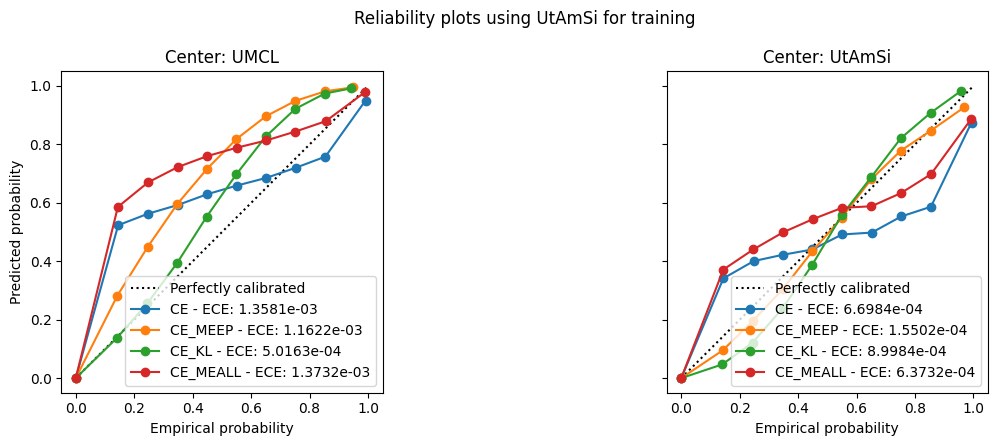

In [7]:
reliability_plots(plot_data)